# Install required packages

In [1]:
import sys
sys.executable

'c:\\Users\\admin\\Desktop\\MovieRecommender\\recommender\\venv\\Scripts\\python.exe'

In [3]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Dataset Exploration

## 2. Dataset Overview

### 2.1 Files and Schema Overview

read the data

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path().resolve().parents[1]  # MovieRecommender
DATA_DIR = (
    PROJECT_ROOT
    / "recommender"   
    / "data"
    / "raw"
    / "ml-small"
    / "ml-latest-small"
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("exists:", DATA_DIR.exists())

links = pd.read_csv(DATA_DIR / "links.csv")
movies = pd.read_csv(DATA_DIR / "movies.csv")
ratings = pd.read_csv(DATA_DIR / "ratings.csv")
tags = pd.read_csv(DATA_DIR / "tags.csv")

PROJECT_ROOT: C:\Users\admin\Desktop\MovieRecommender
DATA_DIR: C:\Users\admin\Desktop\MovieRecommender\recommender\data\raw\ml-small\ml-latest-small
exists: True


In [6]:
print(ratings.head(5))

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [7]:
print(movies.head(5))

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [8]:
print(links.head(5))

   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


In [9]:
print(tags.head(5))

   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2       2    60756     will ferrell  1445714992
3       2    89774     Boxing story  1445715207
4       2    89774              MMA  1445715200


### 2.2  Basic Dataset Statistics

In [10]:
print(movies.shape) #we have 9742 movies
print(links.shape) #this file contains the imdb number and links 
print(ratings.shape)#100836 ratings
print(tags.shape)#3683 tags

(9742, 3)
(9742, 3)
(100836, 4)
(3683, 4)


In [11]:
#Total number of unique users
user_id = ratings['userId']
print(f'number of users = {user_id.nunique()}')
#Average ratings per user
ratings_per_user = ratings.groupby('userId')
# print(ratings_per_user)
mean_per_user = ratings_per_user['rating'].mean()
print(f'average rating per user : {mean_per_user[:5]}')
print(f'overall mean = {mean_per_user.mean()}')
#Total number of unique movies
print(f"unique movies = {movies['movieId'].nunique()}")
#Movies with at least one rating (should match dataset design)
print(ratings["movieId"].nunique())
#average rating per movie
rating_per_movie = ratings.groupby('movieId')['rating'].mean().reset_index()
# print(rating_per_movie.columns)
movie_names_and_ratings = rating_per_movie.merge(movies, on='movieId', how='left')
movie_names_and_ratings = movie_names_and_ratings.sort_values('rating', ascending=False)
# print(movie_names_and_ratings)
# print(rating_per_movie)
#Rating scale confirmation (min, max)
print(min(movie_names_and_ratings['rating']), max(movie_names_and_ratings['rating']))
#Mean rating
print(f"mean rating : {np.mean(movie_names_and_ratings['rating'])}")
#Median rating
print(f"median rating : {np.median(movie_names_and_ratings['rating'])}")
#Standard deviation
print(f"standard deviation of rating : {np.std(movie_names_and_ratings['rating'])}")
df = movies['genres'].str.split('|').explode()
print(f"number of unique genres =  {df.nunique()}")
print(f"unique genres\n\n{df.unique()}")

number of users = 610
average rating per user : userId
1    4.366379
2    3.948276
3    2.435897
4    3.555556
5    3.636364
Name: rating, dtype: float64
overall mean = 3.6572223377474
unique movies = 9742
9724
0.5 5.0
mean rating : 3.262448274810963
median rating : 3.4166666666666665
standard deviation of rating : 0.869828905158302
number of unique genres =  20
unique genres

<StringArray>
[         'Adventure',          'Animation',           'Children',
             'Comedy',            'Fantasy',            'Romance',
              'Drama',             'Action',              'Crime',
           'Thriller',             'Horror',            'Mystery',
             'Sci-Fi',                'War',            'Musical',
        'Documentary',               'IMAX',            'Western',
          'Film-Noir', '(no genres listed)']
Length: 20, dtype: str


### 2.3 User item matrix sparsity

In [12]:
users_ratings = ratings.pivot(index='userId', columns='movieId', values='rating')
print(users_ratings)

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     NaN     4.0     NaN     NaN     4.0     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
...         ...     ...     ...     ...     ...     ...     ...     ...   
606         2.5     NaN     NaN     NaN     NaN     NaN     2.5     NaN   
607         4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
608         2.5     2.0     2.0     NaN     NaN     NaN     NaN     NaN   
609         3.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
610         5.0     NaN     NaN     NaN     NaN     5.0     NaN     NaN   

movieId  9       10     

### 2.4 graphs:

#### User Movie graph

How did the first a users rate first b movies?

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
#how did the first a users rate first b movies?
#we can modify the user_ratings matrixes to show that 
def user_movie_graph(users_num, movies_num, matrix=users_ratings):
    small_df = users_ratings.iloc[:users_num, :movies_num]   
    G = nx.Graph()
    userIds = small_df.index
    movieIds = small_df.columns

    # Add nodes with prefixes so IDs can't collide
    G.add_nodes_from([f"u_{u}" for u in userIds], bipartite=0)   # users
    G.add_nodes_from([f"m_{m}" for m in movieIds], bipartite=1)  # movies

    # Add edges for existing ratings
    for u in userIds:
        for m in movieIds:
            rating = small_df.loc[u, m]
            if not pd.isna(rating) and rating != 0:
                G.add_edge(f"u_{u}", f"m_{m}", weight=rating)

    # Bipartite layout: users left, movies right
    pos = nx.bipartite_layout(G, [f"u_{u}" for u in userIds])

    # Color users green, movies blue
    node_colors = ["green" if str(n).startswith("u_") else "red" for n in G.nodes()]

    plt.figure(figsize=(14, 8))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=3000, font_size=20)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=16)
    plt.title(f"User–Movie Bipartite Graph (First {users_num} Users & First {movies_num} Movies)")
    plt.axis("off")
    plt.show()

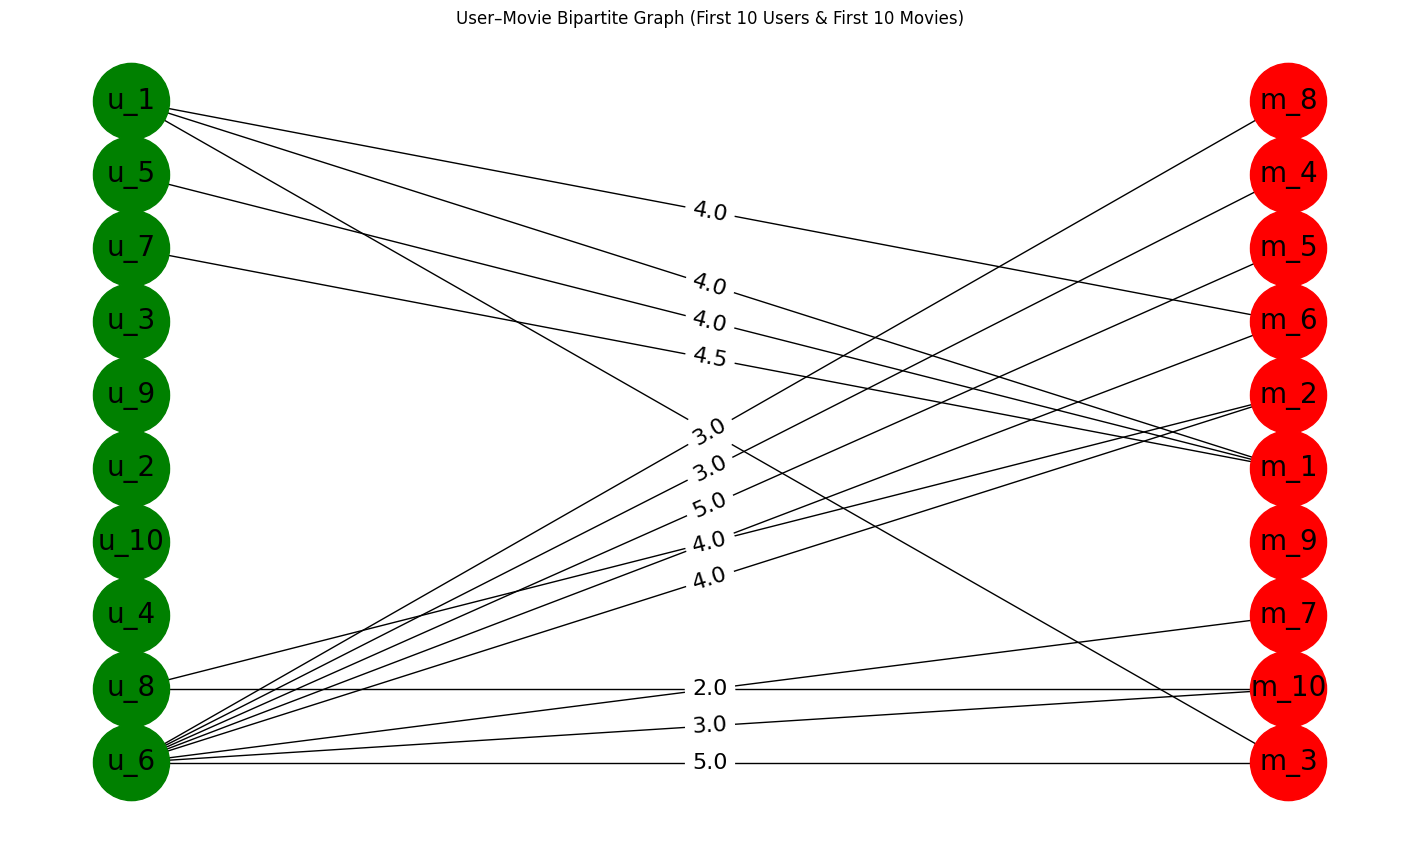

In [14]:
user_movie_graph(10, 10)

#### User User graph

user a is connected to user b if:
 - They have rated the same movie
 - The graph weight between them is the cosine similiraty of movies they have watched

In [15]:
import numpy as np
def distance(u, v, degree):
    #find the movies that both of users rated
    mask = (~np.isnan(u)) & (~np.isnan(v))
    if mask.sum() == 0:
        return np.inf
    u = u[mask]
    v = v[mask]
    return np.sum(np.abs(u - v) ** degree) ** (1.0 / degree)

In [16]:
def similarity(u, v, degree=2):
    dist = distance(u, v, degree)
    return 1.0 / (1.0 + dist)


In [17]:
def user_user_graph(num_users, num_movies, users_ratings, threshold=0.3, degree=2, plot=True):
    small_df = users_ratings.iloc[:num_users, :num_movies]
    user_ids = small_df.index.to_list()

    # build once: matrix rows aligned to user_ids
    X = small_df.to_numpy(dtype=np.float32, copy=False)

    G = nx.Graph()
    G.add_nodes_from(user_ids)

    for i in range(len(user_ids)):
        ui = X[i]
        for j in range(i):
            uj = X[j]
            sim = similarity(ui, uj, degree)  # maps to (0,1]
            if sim >= threshold:
                G.add_edge(user_ids[i], user_ids[j], weight=float(sim))

    if plot:
        plt.figure(figsize=(14, 8))
        pos = nx.spring_layout(G, seed=42)  # stable layout
        nx.draw(G, pos, with_labels=True, node_size=2000, edge_color="gray")

        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)

        plt.title(
            f"User–User Similarity Graph\n"
            f"(first {num_users} users, first {num_movies} movies, degree={degree}, threshold={threshold})"
        )
        plt.axis("off")
        plt.show()

    return G

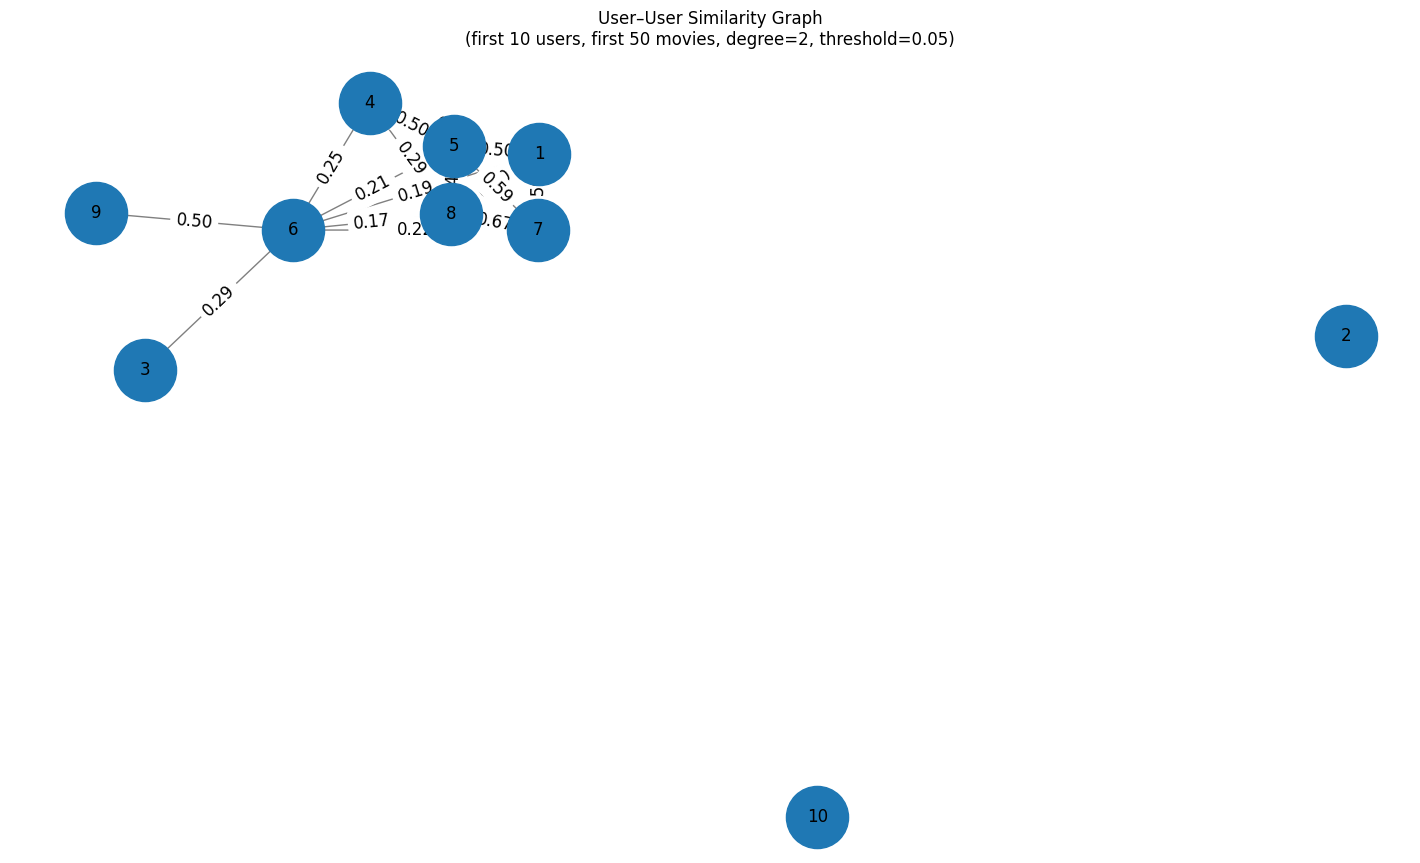

In [19]:
#what is the similarity between first 10 users for first 10 movies
user_user_graph(10, 50, users_ratings, threshold=0.05)

#### Optimization for sparse

In [20]:
def df_to_sparse_rows(df, dtype=np.float32):
    """
    Convert a ratings dataframe (NaNs = missing) into per-user sparse (idx, val).
    Returns:
      user_ids: list
      sparse_rows: list of (idx_arr, val_arr), aligned with user_ids
    """
    user_ids = df.index.to_list()
    X = df.to_numpy(dtype=dtype, copy=False)

    sparse_rows = []
    for i in range(X.shape[0]):
        row = X[i]
        idx = np.flatnonzero(~np.isnan(row))
        val = row[idx]
        sparse_rows.append((idx.astype(np.int32, copy=False), val))
    return user_ids, sparse_rows


In [21]:
# ----------------------------
# 2) Fast sparse distance
# ----------------------------
def sparse_distance(idx_u, val_u, idx_v, val_v, degree=2):
    i = j = 0
    acc = 0.0
    common = 0

    # Two-pointer intersection (idx arrays must be sorted; they are from flatnonzero)
    while i < len(idx_u) and j < len(idx_v):
        a = idx_u[i]
        b = idx_v[j]
        if a == b:
            diff = val_u[i] - val_v[j]
            acc += abs(diff) ** degree
            common += 1
            i += 1
            j += 1
        elif a < b:
            i += 1
        else:
            j += 1

    if common == 0:
        return np.inf, 0  # also return overlap count
    return acc ** (1.0 / degree), common


In [22]:
def similarity_from_sparse(idx_u, val_u, idx_v, val_v, degree=2):
    dist, common = sparse_distance(idx_u, val_u, idx_v, val_v, degree)
    if not np.isfinite(dist):
        return 0.0, 0
    return 1.0 / (1.0 + dist), common


In [23]:
def build_inverted_index(sparse_rows):
    """
    movie -> list of users who rated it
    sparse_rows: list of (idx, val)
    """
    inv = defaultdict(list)
    for user_i, (idx, _) in enumerate(sparse_rows):
        for m in idx:
            inv[int(m)].append(user_i)
    return inv



In [24]:
def user_user_graph_optimized(
    num_users,
    num_movies,
    users_ratings,
    threshold=0.3,
    degree=2,
    min_common=1,          # require at least this many shared movies
    plot=True,
    seed=42,
):
    # Slice once
    small_df = users_ratings.iloc[:num_users, :num_movies]

    # Precompute sparse rows once
    user_ids, sparse_rows = df_to_sparse_rows(small_df)

    # Build inverted index to avoid O(U^2)
    inv = build_inverted_index(sparse_rows)

    G = nx.Graph()
    G.add_nodes_from(user_ids)

    # For each user i, accumulate candidate users j that share at least one movie
    for i, (idx_i, val_i) in enumerate(sparse_rows):
        # Count overlaps with other users using the movies user i rated
        overlap_counts = defaultdict(int)
        for m in idx_i:
            for j in inv[int(m)]:
                if j < i:  # only earlier users to avoid duplicates
                    overlap_counts[j] += 1

        # Only compute similarity for candidates with enough overlap
        for j, common_est in overlap_counts.items():
            if common_est < min_common:
                continue

            idx_j, val_j = sparse_rows[j]
            sim, common = similarity_from_sparse(idx_i, val_i, idx_j, val_j, degree=degree)

            if common >= min_common and sim >= threshold:
                G.add_edge(user_ids[i], user_ids[j], weight=float(sim), common=int(common))

    if plot:
        plt.figure(figsize=(14, 8))
        pos = nx.spring_layout(G, seed=seed)
        nx.draw(G, pos, with_labels=True, node_size=2000, edge_color="gray")
        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)
        plt.title(
            f"User–User Similarity Graph\n"
            f"(users={num_users}, movies={num_movies}, degree={degree}, threshold={threshold}, min_common={min_common})"
        )
        plt.axis("off")
        plt.show()

    return G

In [25]:
import timeit

def run_nonopt():
    user_user_graph(600, 10_000, users_ratings, plot=False)

def run_opt():
    user_user_graph_optimized(600, 10_000, users_ratings, plot=False)

t1 = timeit.timeit(run_nonopt, number=3)
t2 = timeit.timeit(run_opt, number=3)

print("non-optimized avg:", t1/3)
print("optimized avg:", t2/3)

non-optimized avg: 3.8368466666627987
optimized avg: 10.121522866664842


## 3. Ratings Analysis

### 3.1 Overall ratings distribution

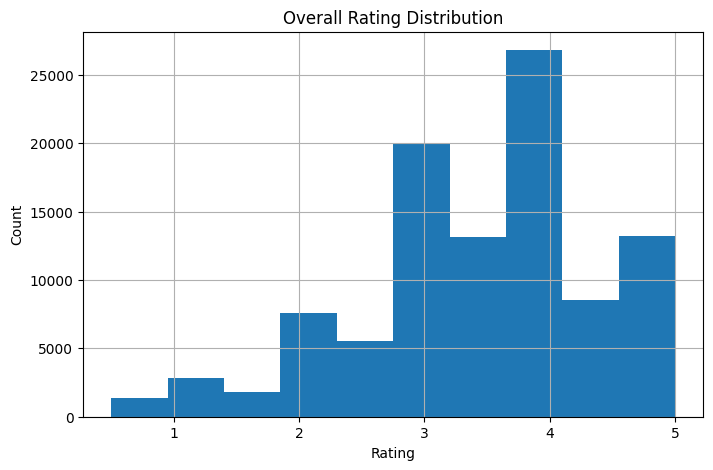

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
ratings['rating'].hist(bins=10)
plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### 3.2 Rating Per Movie distribution

#### Most rated movies

In [4]:
movie_stats = ratings.groupby('movieId')['rating']
movie_stats_df = movie_stats.agg(['mean', 'count', 'std']).reset_index()
movie_stats_df = movie_stats_df.merge(movies, on='movieId', how='left')
movie_stats_df.sort_values(['count', 'mean'], ascending=[False, False], inplace=True)
print(movie_stats_df[['movieId', 'title', 'count', 'mean']])

      movieId                             title  count      mean
314       356               Forrest Gump (1994)    329  4.164134
277       318  Shawshank Redemption, The (1994)    317  4.429022
257       296               Pulp Fiction (1994)    307  4.197068
510       593  Silence of the Lambs, The (1991)    279  4.161290
1938     2571                Matrix, The (1999)    278  4.192446
...       ...                               ...    ...       ...
9401   165645                Bad Santa 2 (2016)      1  0.500000
9426   167296                   Iron Man (1931)      1  0.500000
9540   173307    The Gracefield Incident (2015)      1  0.500000
9572   175475            The Emoji Movie (2017)      1  0.500000
9675   184641   Fullmetal Alchemist 2018 (2017)      1  0.500000

[9724 rows x 4 columns]


#### Very few rated movies

In [29]:
movie_stats_filtered = movie_stats_df[movie_stats_df['count'] < 5]
movie_stats_sorted = movie_stats_filtered.sort_values(
    by='mean',
    ascending=False
)

print(f'number of movies with less than 5 reviewers = {len(movie_stats_sorted)}')
print(movie_stats_sorted)

number of movies with less than 5 reviewers = 6074
      movieId  mean  count  std  \
1036     1349   5.0      1  NaN   
1005     1310   5.0      1  NaN   
864      1140   5.0      1  NaN   
666       876   5.0      1  NaN   
536       633   5.0      1  NaN   
...       ...   ...    ...  ...   
6987    67799   0.5      1  NaN   
9426   167296   0.5      1  NaN   
9540   173307   0.5      1  NaN   
9572   175475   0.5      1  NaN   
9675   184641   0.5      1  NaN   

                                                  title  \
1036  Vampire in Venice (Nosferatu a Venezia) (Nosfe...   
1005                                       Hype! (1996)   
864   Entertaining Angels: The Dorothy Day Story (1996)   
666      Supercop 2 (Project S) (Chao ji ji hua) (1993)   
536                              Denise Calls Up (1995)   
...                                                 ...   
6987         The Butterfly Effect 3: Revelations (2009)   
9426                                    Iron Man (1931) 

### 3.3 Rating per user distribution

In [136]:
user_ratings = ratings.groupby('userId')['rating'].aggregate(
    count = 'count',   
).reset_index()
user_ratings_sorted = user_ratings.sort_values(
    by='count',
    ascending=False
)
print(user_ratings_sorted.head(50)) 
# this would make users who rated the most movies

     userId  count
413     414   2698
598     599   2478
473     474   2108
447     448   1864
273     274   1346
609     610   1302
67       68   1260
379     380   1218
605     606   1115
287     288   1055
248     249   1046
386     387   1027
181     182    977
306     307    975
602     603    943
297     298    939
176     177    904
317     318    879
231     232    862
479     480    836
607     608    831
599     600    763
589     590    728
482     483    728
104     105    722
18       19    703
304     305    677
488     489    648
110     111    646
437     438    635
216     217    613
139     140    608
476     477    600
554     555    578
90       91    575
27       28    570
218     219    528
533     534    520
88       89    518
63       64    517
225     226    507
560     561    505
17       18    502
524     525    500
56       57    476
380     381    474
367     368    469
508     509    467
468     469    465
559     560    458


#### users who rated +50 movies

In [137]:
filtered = user_ratings_sorted[user_ratings_sorted['count'] > 50]
#378 userids rated more than 50 movies!
print(len(filtered))

378


#### lorenze curve

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lorenz_curve(ratings_per_user):
    """
    ratings_per_user: 1D array-like of number of ratings per user
    """

    # Convert & sort
    x = np.array(ratings_per_user)
    x = np.sort(x)

    # Cumulative sums
    cum_ratings = np.cumsum(x)
    cum_ratings_share = cum_ratings / cum_ratings[-1]

    # Cumulative user share
    n = len(x)
    cum_users_share = np.arange(1, n + 1) / n

    # Add (0,0)
    cum_users_share = np.insert(cum_users_share, 0, 0)
    cum_ratings_share = np.insert(cum_ratings_share, 0, 0)

    # Plot
    plt.figure()
    plt.plot(cum_users_share, cum_ratings_share, label="Lorenz curve")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Equality line")
    plt.xlabel("Cumulative share of users")
    plt.ylabel("Cumulative share of ratings")
    plt.legend()
    plt.title("Lorenz Curve: Ratings per User")
    plt.show()

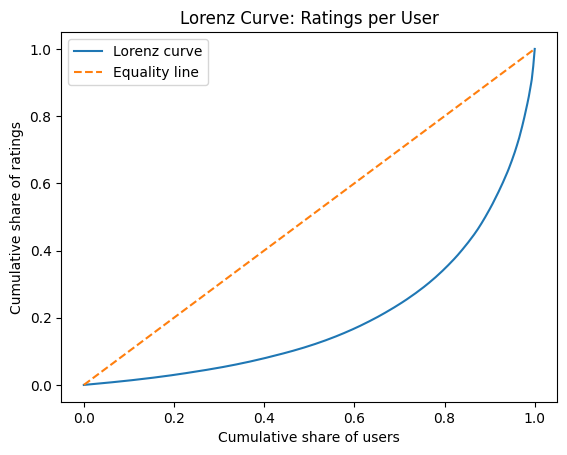

In [138]:
user_ratings = ratings.groupby('userId')['rating'].aggregate(
    count='count'
).reset_index()
user_ratings_sorted = user_ratings.sort_values(
    by='count',
    ascending=True
)
import numpy as np
import matplotlib.pyplot as plt

counts = user_ratings_sorted['count'].values

# Cumulative ratings share
cum_ratings = np.cumsum(counts)
cum_ratings_share = cum_ratings / cum_ratings[-1]

# Cumulative user share
n_users = len(counts)
cum_users_share = np.arange(1, n_users + 1) / n_users

# Add origin (0,0)
cum_users_share = np.insert(cum_users_share, 0, 0)
cum_ratings_share = np.insert(cum_ratings_share, 0, 0)
plt.figure()
plt.plot(cum_users_share, cum_ratings_share, label='Lorenz curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Equality line')
plt.xlabel('Cumulative share of users')
plt.ylabel('Cumulative share of ratings')
plt.title('Lorenz Curve: Ratings per User')
plt.legend()
plt.show()

In [139]:
def gini_from_counts(counts):
    counts = np.sort(counts)
    n = len(counts)
    cum_counts = np.cumsum(counts)
    return (n + 1 - 2 * np.sum(cum_counts) / cum_counts[-1]) / n

gini = gini_from_counts(user_ratings['count'].values)
print(f"Gini coefficient: {gini:.3f}")

Gini coefficient: 0.604


In [140]:
import numpy as np

counts = np.sort(user_ratings['count'].values)

cum_ratings_share = np.cumsum(counts) / counts.sum()
cum_users_share = np.arange(1, len(counts) + 1) / len(counts)

# Find % users needed for 50% of ratings
power_user_share = cum_users_share[cum_ratings_share >= 0.5][0]

print(f"{power_user_share*100:.1f}% of users generate 50% of ratings")

89.2% of users generate 50% of ratings


User contributions are highly skewed: 10.8% of users account for 50% of all ratings (bias risk)
Roughly one in ten users drives half of all rating activity.

### 3.4 Bias analysis

#### 1. Popularity bias

Popular movies get recommended and predicted better than niche ones

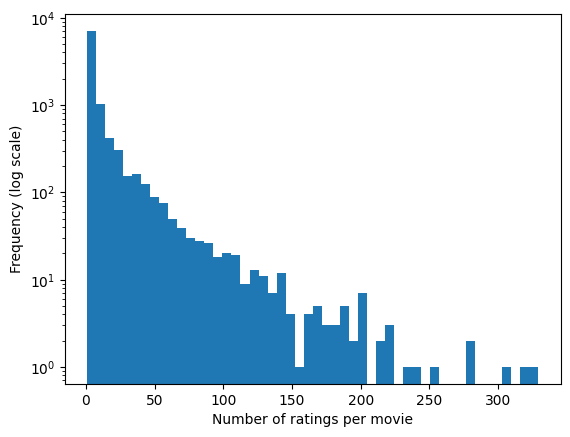

In [52]:
num_rating_per_movie = ratings.groupby('movieId')['rating'].count()
plt.hist(num_rating_per_movie, bins=50)
plt.yscale('log')
plt.xlabel("Number of ratings per movie")
plt.ylabel("Frequency (log scale)")
plt.show()

Many Movies have small number of ratings and only a few movies have more than 250 ratings

In [53]:
ratings_per_movie = ratings.groupby("movieId")["rating"].count()
top_10_percent = ratings_per_movie.sort_values(ascending=False)[:int(len(ratings_per_movie)*0.1)]
share = top_10_percent.sum() / ratings_per_movie.sum()

print("Top 10% movies hold:", share*100, "% of ratings")

Top 10% movies hold: 60.02221428854774 % of ratings


##### Popular Movies

In [55]:
ratings_per_movie = ratings.groupby("movieId")["rating"].count()

# Filter movies with more than 250 ratings
movies_with_more_250_rating = ratings_per_movie[ratings_per_movie > 250]

# Compute share of total ratings
share = movies_with_more_250_rating.sum() / ratings_per_movie.sum()

print(f"Movies with more than 250 ratings account for {share * 100:.2f}% of all ratings")

Movies with more than 250 ratings account for 1.75% of all ratings


##### Unpopular Movies

In [ ]:
ratings_per_movie = ratings.groupby("movieId")["rating"].count()

# Filter movies with less than 5 ratings
movies_lt_5_rating = ratings_per_movie[ratings_per_movie < 5]

# Compute share of total ratings
share = movies_lt_5_rating.sum() / ratings_per_movie.sum()

print(f"Movies with less than 5 ratings account for {share * 100:.2f}% of all ratings")

Movies with less than 5 ratings account for 12.37% of all ratings


##### does popularity relate to rating?

In [58]:
avg_rating = ratings.groupby("movieId")["rating"].mean()
popularity = ratings.groupby("movieId")["rating"].count()

correlation = avg_rating.corr(popularity)
print(correlation)

0.1272585735956063


##### Rating Mean vs avg Std 

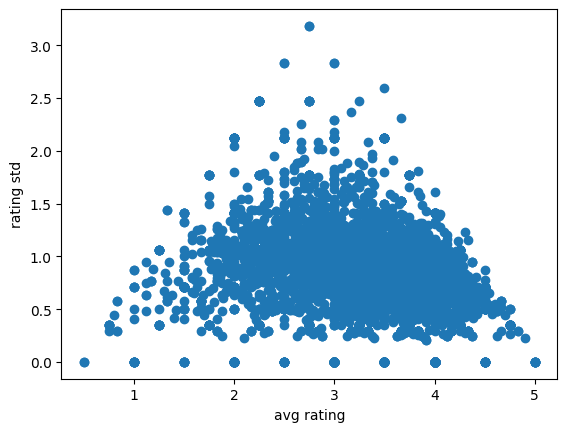

In [62]:
rating_std = ratings.groupby("movieId")["rating"].std()
plt.xlabel('avg rating')
plt.ylabel('rating std')
plt.scatter(avg_rating, rating_std)

Rating variability is highest for movies with mid-range average ratings and lower near the rating scale boundaries. Highly rated movies tend to have lower disagreement, while moderately rated movies show more polarization.

##### Rating count vs Avg std

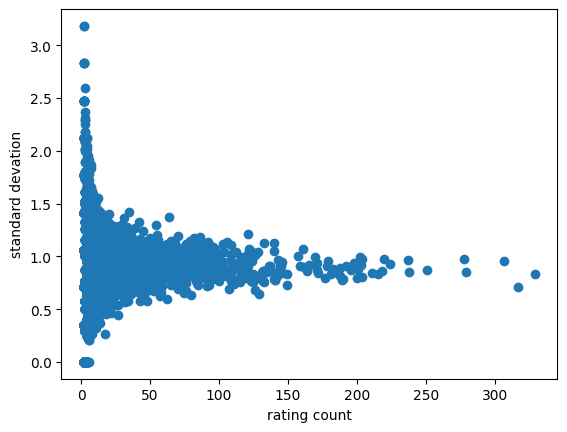

In [61]:
rating_count = ratings.groupby('movieId')['rating'].count()
plt.xlabel('rating count')
plt.ylabel('standard devation')
plt.scatter(rating_count, rating_std)

Movies with low rating counts exhibit significantly higher variance in ratings. This indicates that average ratings for unpopular movies are statistically unstable. Popular movies show convergence in rating variability, making their averages more reliable.

##### Popular vs Unpopular movies

In [73]:
ratings_per_movie = ratings.groupby("movieId")["rating"].count()


unpopular_movies = ratings_per_movie[(ratings_per_movie > 1) & (ratings_per_movie <= 5)].index
popular_movies = ratings_per_movie[ratings_per_movie >= 100].index

In [74]:
avg_rating = ratings.groupby("movieId")["rating"].mean()
rating_std = ratings.groupby("movieId")["rating"].std()

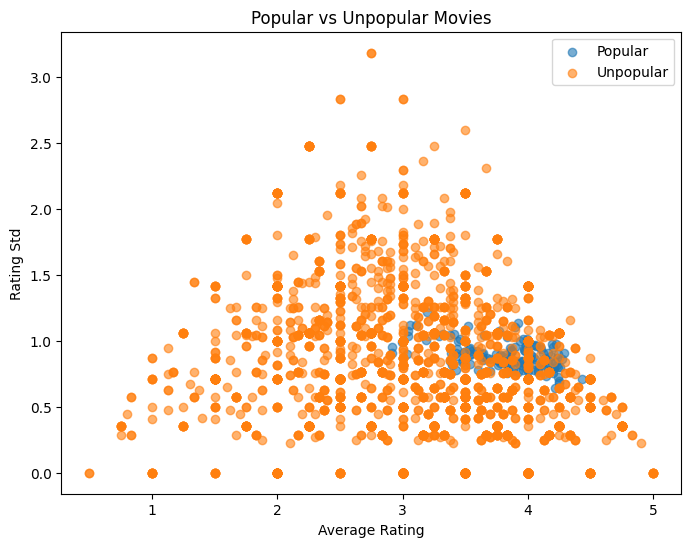

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Popular movies
plt.scatter(
    avg_rating.loc[popular_movies],
    rating_std.loc[popular_movies],
    alpha=0.6,
    label="Popular"
)

# Unpopular movies
plt.scatter(
    avg_rating.loc[unpopular_movies],
    rating_std.loc[unpopular_movies],
    alpha=0.6,
    label="Unpopular"
)

plt.xlabel("Average Rating")
plt.ylabel("Rating Std")
plt.legend()
plt.title("Popular vs Unpopular Movies")
plt.show()

The plot shows a clear difference between popular and unpopular movies in terms of rating stability. Popular movies (blue points) cluster tightly around higher average ratings (roughly 3.5–4.2) with relatively low standard deviation (around 0.7–1.1), indicating consistent user agreement. In contrast, unpopular movies (orange points) are much more dispersed across both average rating and standard deviation, with many exhibiting higher variability and extreme values. This suggests that popular movies have more stable and reliable rating patterns due to larger sample sizes, while unpopular movies are statistically unstable and more prone to rating volatility, reinforcing the structural imbalance that contributes to popularity bias.

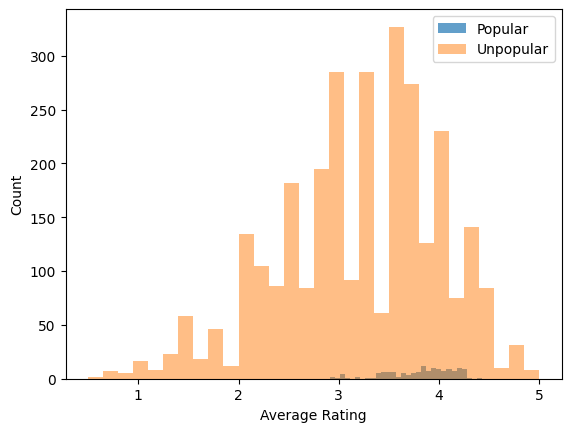

In [78]:
plt.hist(avg_rating.loc[popular_movies], bins=30, alpha=0.7, label="Popular")
plt.hist(avg_rating.loc[unpopular_movies], bins=30, alpha=0.5, label="Unpopular")
plt.legend()
plt.xlabel("Average Rating")
plt.ylabel("Count")
plt.show()

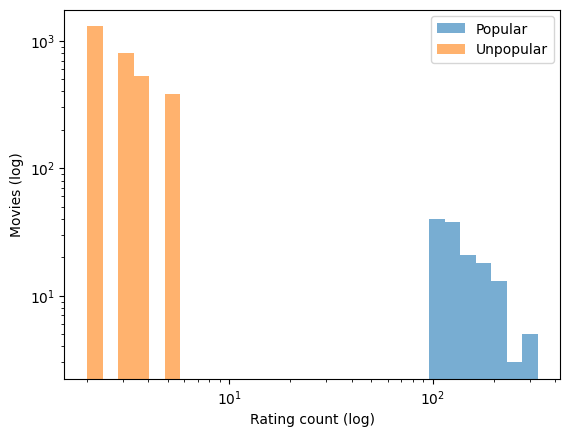

In [86]:
import numpy as np
import matplotlib.pyplot as plt

pop_counts = ratings_per_movie.loc[popular_movies]
unpop_counts = ratings_per_movie.loc[unpopular_movies]

# log-spaced bin edges spanning both groups
bins = np.logspace(np.log10(min(unpop_counts.min(), pop_counts.min())),
                   np.log10(max(unpop_counts.max(), pop_counts.max())),
                   30)

plt.hist(pop_counts, bins=bins, alpha=0.6, label="Popular")
plt.hist(unpop_counts, bins=bins, alpha=0.6, label="Unpopular")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rating count (log)")
plt.ylabel("Movies (log)")
plt.legend()
plt.show()

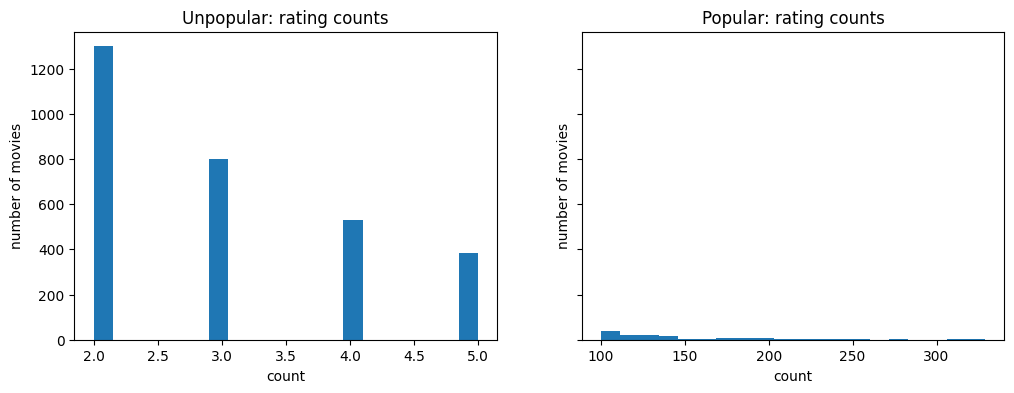

In [88]:
pop_counts = ratings_per_movie.loc[popular_movies]
unpop_counts = ratings_per_movie.loc[unpopular_movies]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(unpop_counts, bins=20)
axes[0].set_title("Unpopular: rating counts")
axes[0].set_xlabel("count")

axes[1].hist(pop_counts, bins=20)
axes[1].set_title("Popular: rating counts")
axes[1].set_xlabel("count")

axes[0].set_ylabel("number of movies")
axes[1].set_ylabel('number of movies')
plt.show()

#### 2. User activity bias

Models work better for users who rate a lot of movies.

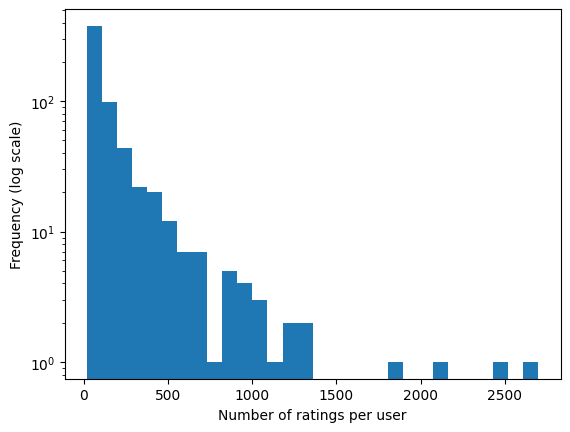

In [97]:
ratings_per_user = ratings.groupby('userId')['rating'].count()
ratings_per_user.sort_values(inplace=True, ascending=False)
plt.hist(ratings_per_user, bins=30)
plt.yscale("log")
plt.xlabel("Number of ratings per user")
plt.ylabel("Frequency (log scale)")
plt.show()

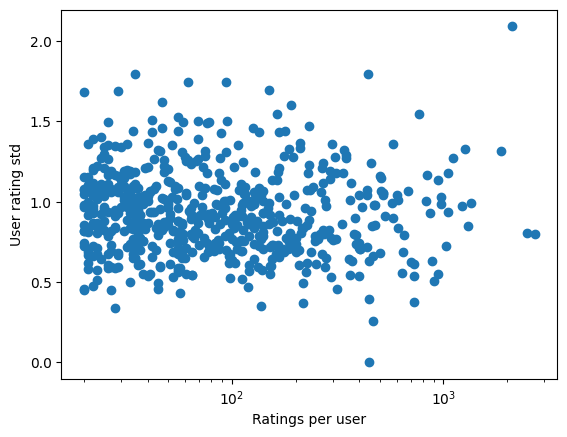

In [98]:
user_std = ratings.groupby("userId")["rating"].std()

plt.scatter(ratings_per_user, user_std)
plt.xscale("log")
plt.xlabel("Ratings per user")
plt.ylabel("User rating std")
plt.show()

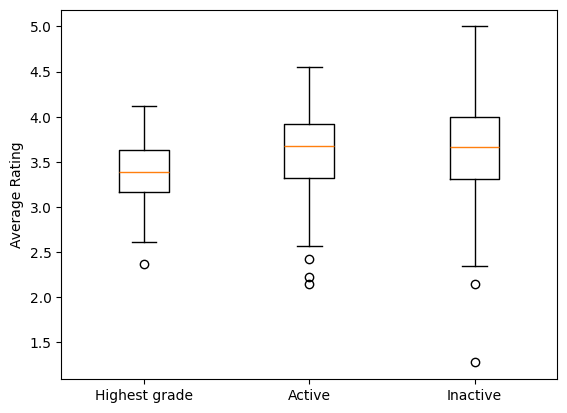

In [104]:
highest_grade_users = ratings_per_user[ratings_per_user >= 500].index

active_users = ratings_per_user[
    (ratings_per_user >= 100) & (ratings_per_user < 200)
].index

inactive_users = ratings_per_user[
    ratings_per_user < 30
].index
avg_rating_per_user = ratings.groupby("userId")["rating"].mean()
plt.boxplot([
    avg_rating_per_user[highest_grade_users],
    avg_rating_per_user[active_users],
    avg_rating_per_user[inactive_users]
])
plt.xticks([1,2, 3], ["Highest grade", "Active", "Inactive"])
plt.ylabel("Average Rating")
plt.show()

The boxplot shows clear differences in average rating behavior across user activity levels. Highly active users (500+ ratings) have the lowest median average rating (around ~3.4) and the tightest spread, suggesting they are slightly more critical and consistent in their scoring. Moderately active users (100–200 ratings) show a higher median (around ~3.6–3.7) with moderate variability. Inactive users (<30 ratings) display the widest spread and the most extreme outliers, including both very low and very high average ratings, indicating less stable and more polarized behavior. Overall, heavier users tend to be more consistent and slightly stricter, while less active users exhibit greater variability and more extreme rating tendencies, which has implications for user-bias normalization in collaborative models.


##### Rating per user

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# user-item matrix (rows users, columns movies)
users_ratings = ratings.pivot_table(index="userId", columns="movieId", values="rating")

# We'll use binary interactions (rated or not) to focus on activity signal
X = users_ratings.notna().astype(int)

In [106]:
ratings_per_user = ratings.groupby("userId")["rating"].count()

In [107]:
inactive_users = ratings_per_user[ratings_per_user < 30].index
active_users   = ratings_per_user[(ratings_per_user >= 100) & (ratings_per_user < 200)].index
power_users    = ratings_per_user[ratings_per_user >= 500].index

In [108]:
from sklearn.metrics.pairwise import cosine_similarity

# cosine similarity between users based on binary interactions
sim = cosine_similarity(X.values)

# map matrix rows to actual userIds
user_ids = X.index.to_numpy()
uid_to_idx = {uid: i for i, uid in enumerate(user_ids)}

In [109]:
def top_neighbor_similarity(uids):
    idxs = [uid_to_idx[u] for u in uids if u in uid_to_idx]
    top_sims = []
    for i in idxs:
        row = sim[i].copy()
        row[i] = -1  # exclude self similarity
        top_sims.append(row.max())
    return np.array(top_sims)

inactive_top = top_neighbor_similarity(inactive_users)
active_top   = top_neighbor_similarity(active_users)
power_top    = top_neighbor_similarity(power_users)

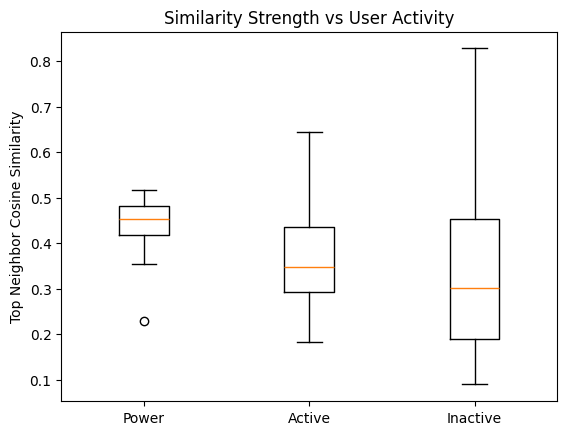

In [110]:
plt.boxplot([power_top, active_top, inactive_top])
plt.xticks([1,2,3], ["Power", "Active", "Inactive"])
plt.ylabel("Top Neighbor Cosine Similarity")
plt.title("Similarity Strength vs User Activity")
plt.show()

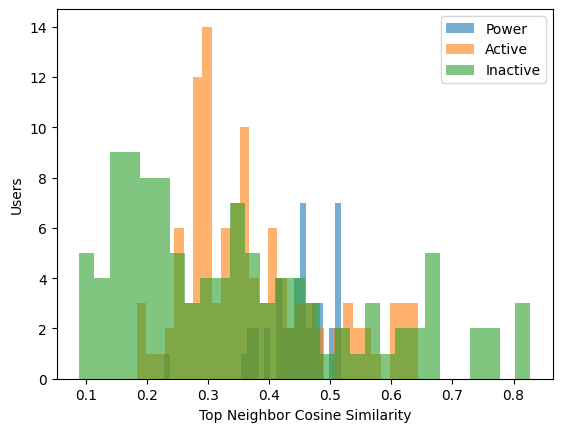

In [111]:
plt.hist(power_top, bins=30, alpha=0.6, label="Power")
plt.hist(active_top, bins=30, alpha=0.6, label="Active")
plt.hist(inactive_top, bins=30, alpha=0.6, label="Inactive")
plt.xlabel("Top Neighbor Cosine Similarity")
plt.ylabel("Users")
plt.legend()
plt.show()

In [112]:
def summarize(name, arr):
    print(name)
    print("n =", len(arr))
    print("mean =", arr.mean())
    print("median =", np.median(arr))
    print("p90 =", np.quantile(arr, 0.9))
    print()

summarize("Power", power_top)
summarize("Active", active_top)
summarize("Inactive", inactive_top)

Power
n = 44
mean = 0.44597490702933806
median = 0.45277533009038406
p90 = 0.51136093721111

Active
n = 114
mean = 0.3743446181386456
median = 0.3477648074644488
p90 = 0.5542648519412304

Inactive
n = 109
mean = 0.34924347725344296
median = 0.30016680568428156
p90 = 0.6621949437569076



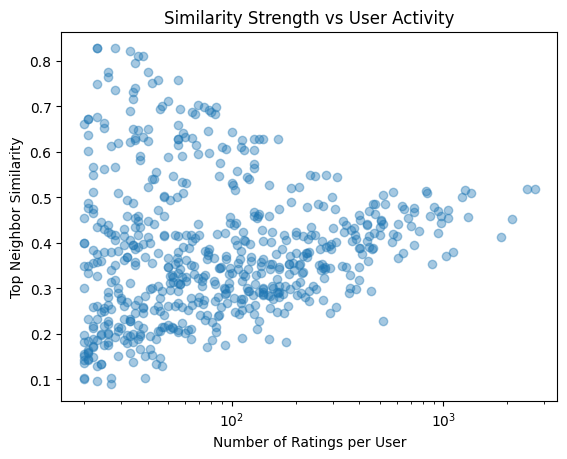

In [113]:
# similarity strength for all users
all_top = top_neighbor_similarity(ratings_per_user.index)

plt.scatter(ratings_per_user, all_top, alpha=0.4)
plt.xscale("log")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Top Neighbor Similarity")
plt.title("Similarity Strength vs User Activity")
plt.show()

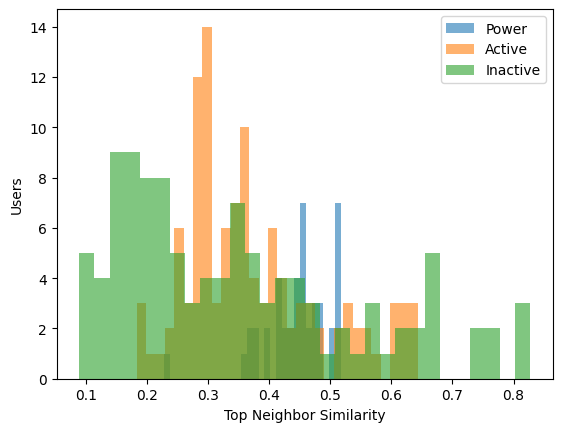

In [114]:
plt.hist(power_top, bins=30, alpha=0.6, label="Power")
plt.hist(active_top, bins=30, alpha=0.6, label="Active")
plt.hist(inactive_top, bins=30, alpha=0.6, label="Inactive")
plt.xlabel("Top Neighbor Similarity")
plt.ylabel("Users")
plt.legend()
plt.show()

##### Cosine similarity per user group

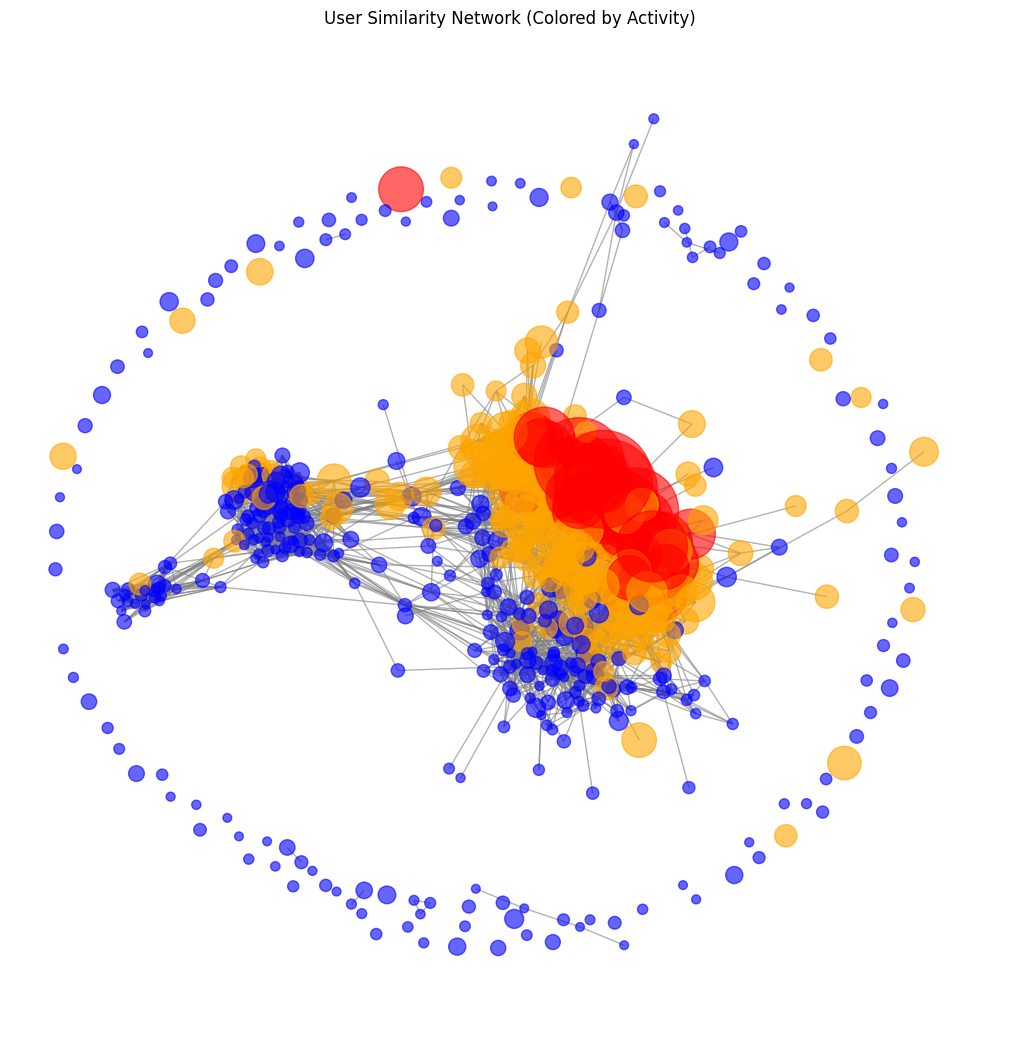

In [119]:
sim = cosine_similarity(X.values)
user_ids = X.index.to_numpy()
import networkx as nx

G = nx.Graph()
min_sim = 0.25
# Add nodes
for uid in user_ids:
    G.add_node(uid)
k = 10

for i, uid in enumerate(user_ids):
    row = sim[i].copy()
    row[i] = -1  # remove self

    top_k_idx = np.argsort(row)[-k:]

    for j in top_k_idx:
        if row[j] > min_sim :  # optional threshold
            G.add_edge(uid, user_ids[j], weight=row[j])
ratings_per_user = ratings.groupby("userId")["rating"].count()

node_sizes = [
    ratings_per_user.get(uid, 1) * 2
    for uid in G.nodes()
]
colors = []
for uid in G.nodes():
    count = ratings_per_user.get(uid, 0)
    if count >= 500:
        colors.append("red")      # power users
    elif count >= 100:
        colors.append("orange")   # active
    else:
        colors.append("blue")     # inactive
plt.figure(figsize=(10,10))

pos = nx.spring_layout(G, k=0.15)

nx.draw(
    G,
    pos,
    node_size=node_sizes,
    node_color=colors,
    edge_color="gray",
    alpha=0.6,
    with_labels=False
)

plt.title("User Similarity Network (Colored by Activity)")
plt.show()                        

##### graph degree per activity

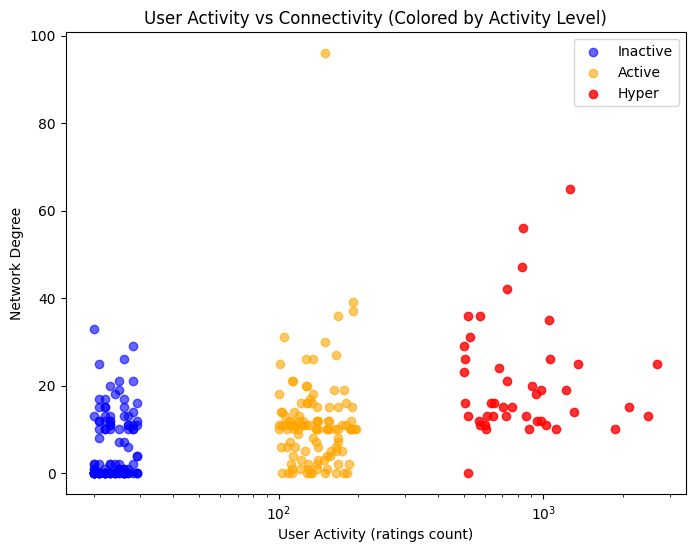

In [121]:
degrees = dict(G.degree())

# Build arrays per group
inactive_x = []
inactive_y = []

active_x = []
active_y = []

highest_x = []
highest_y = []

for u, deg in degrees.items():
    activity = ratings_per_user[u]

    if u in power_users:
        highest_x.append(activity)
        highest_y.append(deg)

    elif u in active_users:
        active_x.append(activity)
        active_y.append(deg)

    elif u in inactive_users:
        inactive_x.append(activity)
        inactive_y.append(deg)
plt.figure(figsize=(8,6))

plt.scatter(inactive_x, inactive_y, alpha=0.6, label="Inactive", color="blue")
plt.scatter(active_x, active_y, alpha=0.6, label="Active", color="orange")
plt.scatter(highest_x, highest_y, alpha=0.8, label="Hyper", color="red")

plt.xscale("log")
plt.xlabel("User Activity (ratings count)")
plt.ylabel("Network Degree")
plt.title("User Activity vs Connectivity (Colored by Activity Level)")
plt.legend()
plt.show()        
        

User connectivity in the similarity network increases with rating activity. Hyper users occupy highly connected regions of the network, while inactive users lie on the periphery with few similarity links. This structural property suggests collaborative filtering will perform better for active users and struggle with sparse-user representations, reinforcing the need for hybrid or cold-start handling strategies.

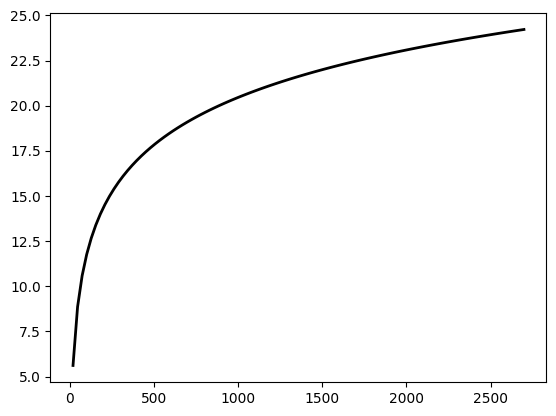

In [122]:
import numpy as np

x_all = np.array([ratings_per_user[u] for u in degrees.keys()])
y_all = np.array(list(degrees.values()))

coeff = np.polyfit(np.log(x_all), y_all, 1)
x_line = np.linspace(min(x_all), max(x_all), 100)
y_line = coeff[0] * np.log(x_line) + coeff[1]

plt.plot(x_line, y_line, color="black", linewidth=2)

#### 3. Rating scale bias

Users use the 1–5 scale differently.

count    610.000000
mean       3.657222
std        0.480635
min        1.275000
25%        3.360000
50%        3.694385
75%        3.997500
max        5.000000
Name: rating, dtype: float64


<Axes: >

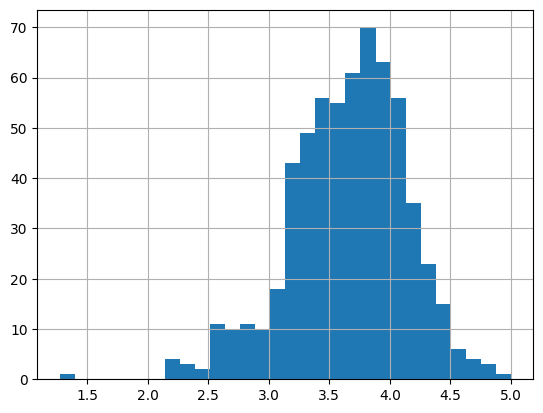

In [123]:
user_mean = ratings.groupby('userId')['rating'].mean()
print(user_mean.describe())
user_mean.hist(bins=30)

1
10
50


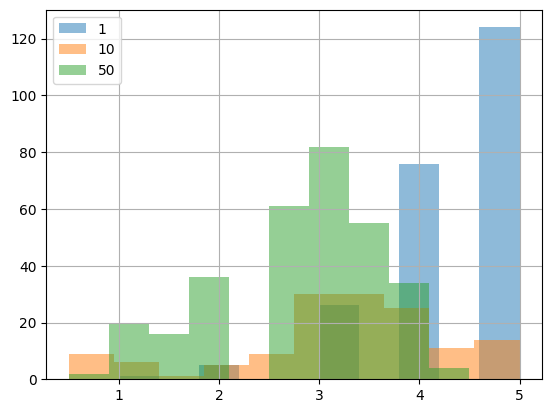

In [ ]:
import matplotlib.pyplot as plt

for u in [1, 10, 50]:
    ratings[ratings['userId'] == u]['rating'].hist(alpha=0.5)

plt.legend([1, 10, 50])
plt.show()

In [127]:
user_stats = ratings.groupby('userId')['rating'].agg(['mean','std','count'])
user_stats.sort_values('mean').head()

,mean,std,count
userId,,,
442,1.275000,0.697269,20
139,2.144330,0.894597,194
508,2.145833,1.057881,24
153,2.217877,1.431984,179
567,2.245455,1.221076,385


In [128]:
user_stats.sort_values('mean').tail()

,mean,std,count
userId,,,
30,4.735294,0.553711,34
25,4.807692,0.376216,26
515,4.846154,0.339683,26
251,4.869565,0.526942,23
53,5.000000,0.000000,20


#### 4. Temporal bias

Older movies benefit from more historical data

In [130]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['year'] = movies['year'].astype(float)

ratings_per_movie = ratings.groupby('movieId').size().reset_index(name='rating_count')

movies_with_counts = movies.merge(ratings_per_movie, on='movieId', how='left')
print(movies_with_counts.head(2))

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        2    Jumanji (1995)                   Adventure|Children|Fantasy   

     year  rating_count  
0  1995.0         215.0  
1  1995.0         110.0  


<Axes: xlabel='year'>

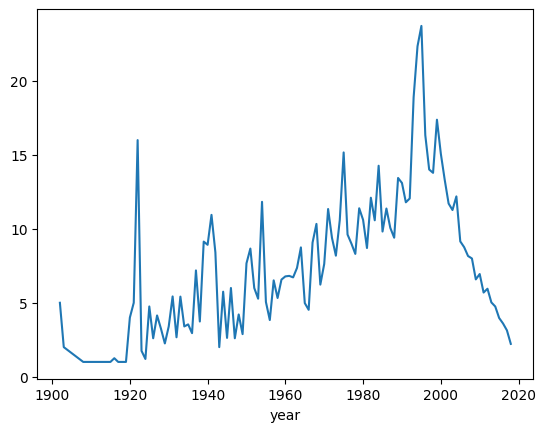

In [131]:
movies_with_counts.groupby('year')['rating_count'].mean().plot()

In [133]:
very_old_movies = movies_with_counts[movies_with_counts['year'] < 1950]['movieId']

old_movies = movies_with_counts[
    (movies_with_counts['year'] >= 1950) & 
    (movies_with_counts['year'] < 1990)
]['movieId']

moderate_old_movies = movies_with_counts[
    (movies_with_counts['year'] >= 1990) & 
    (movies_with_counts['year'] < 2010)
]['movieId']

new_movies = movies_with_counts[
    (movies_with_counts['year'] >= 2010)
]['movieId']

In [134]:
def avg_rating_count(movie_ids):
    return movies_with_counts[
        movies_with_counts['movieId'].isin(movie_ids)
    ]['rating_count'].mean()

print("Very old:", avg_rating_count(very_old_movies))
print("Old:", avg_rating_count(old_movies))
print("Moderate old:", avg_rating_count(moderate_old_movies))
print("New:", avg_rating_count(new_movies))

Very old: 5.144
Old: 9.599404001702853
Moderate old: 13.219893217322523
New: 4.915544041450778


Movies released between 1990–2010 have significantly higher interaction density compared to both very old and recent movies. This suggests exposure bias tied to peak dataset activity rather than simple age-based accumulation. Recommender v1 must account for this imbalance to prevent era dominance.

## 4. Temporal Analysis

In [141]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['year'] = movies['year'].astype(float)

ratings_per_movie = ratings.groupby('movieId').size().reset_index(name='rating_count')

movies_with_counts = movies.merge(ratings_per_movie, on='movieId', how='left')
print(movies_with_counts.head(2))

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        2    Jumanji (1995)                   Adventure|Children|Fantasy   

     year  rating_count  
0  1995.0         215.0  
1  1995.0         110.0  


### 4.1 Rating over time

In [142]:
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s', utc=True)
ratings['date'] = ratings['datetime'].dt.date
ratings['year'] = ratings['datetime'].dt.year
ratings['month'] = ratings['datetime'].dt.month
ratings['year_month'] = ratings['datetime'].dt.to_period('M').astype(str)

C:\Users\admin\AppData\Local\Temp\ipykernel_11492\645892936.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ratings['year_month'] = ratings['datetime'].dt.to_period('M').astype(str)


In [143]:
print(ratings)

        userId  movieId  rating   timestamp                  datetime  \
0            1        1     4.0   964982703 2000-07-30 18:45:03+00:00   
1            1        3     4.0   964981247 2000-07-30 18:20:47+00:00   
2            1        6     4.0   964982224 2000-07-30 18:37:04+00:00   
3            1       47     5.0   964983815 2000-07-30 19:03:35+00:00   
4            1       50     5.0   964982931 2000-07-30 18:48:51+00:00   
...        ...      ...     ...         ...                       ...   
100831     610   166534     4.0  1493848402 2017-05-03 21:53:22+00:00   
100832     610   168248     5.0  1493850091 2017-05-03 22:21:31+00:00   
100833     610   168250     5.0  1494273047 2017-05-08 19:50:47+00:00   
100834     610   168252     5.0  1493846352 2017-05-03 21:19:12+00:00   
100835     610   170875     3.0  1493846415 2017-05-03 21:20:15+00:00   

              date  year  month year_month  
0       2000-07-30  2000      7    2000-07  
1       2000-07-30  2000      7  

#### 4.1.1 Activity growth over years

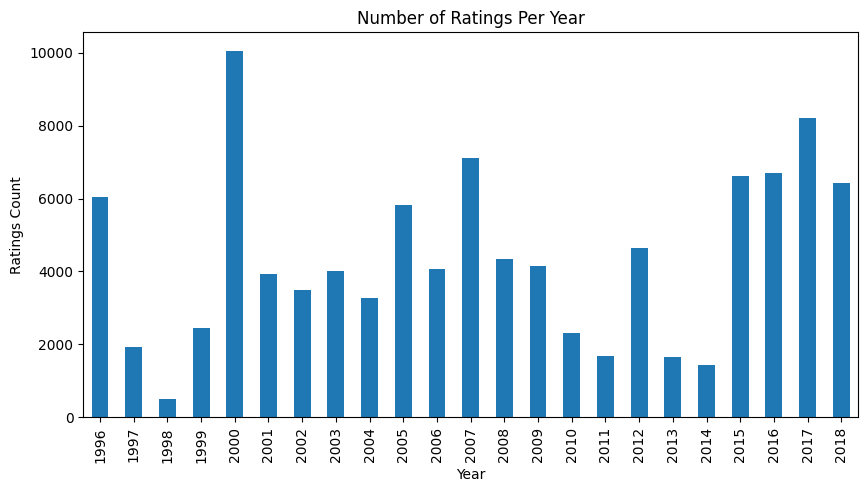

In [150]:
rating_count_year = ratings.groupby('year')['rating'].agg(
    ['count', 'mean', 'median']
)
rating_count_year['count'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Number of Ratings Per Year")
plt.xlabel("Year")
plt.ylabel("Ratings Count")
plt.show()

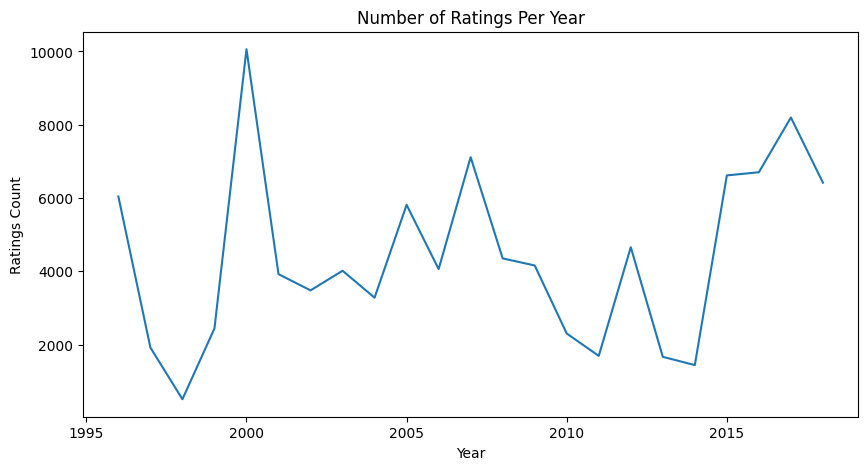

In [151]:
rating_count_year['count'].plot(
    figsize=(10,5)
)

plt.title("Number of Ratings Per Year")
plt.xlabel("Year")
plt.ylabel("Ratings Count")
plt.show()

The user–item matrix density declines over time and stabilizes around 4–6%, indicating extreme sparsity. This suggests that pure collaborative filtering may struggle due to limited overlap between users. A hybrid recommendation approach combining collaborative and content-based signals is likely necessary. Additionally, cold-start users will require onboarding support.

In [152]:
#density
yearly_stats = ratings.groupby('year').agg(
    ratings_count=('rating', 'count'),
    active_users=('userId', 'nunique'),
    active_movies=('movieId', 'nunique')
)

yearly_stats['density'] = (
    yearly_stats['ratings_count'] /
    (yearly_stats['active_users'] * yearly_stats['active_movies'])
)

print(yearly_stats)

      ratings_count  active_users  active_movies   density
year                                                      
1996           6040            97            607  0.102583
1997           1916            33            649  0.089462
1998            507            11            333  0.138411
1999           2439            27           1013  0.089174
2000          10061            56           2380  0.075488
2001           3922            38           1831  0.056368
2002           3478            25           1713  0.081214
2003           4014            31           2078  0.062312
2004           3279            24           1821  0.075027
2005           5813            43           2380  0.056801
2006           4059            43           1571  0.060086
2007           7114            46           2881  0.053680
2008           4351            41           1879  0.056478
2009           4158            45           2106  0.043875
2010           2301            36           1392  0.0459

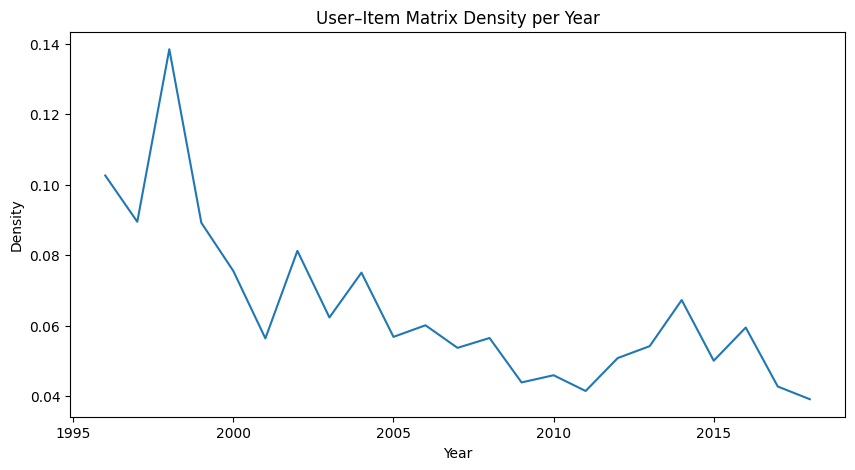

In [153]:
yearly_stats['density'].plot(figsize=(10,5))
plt.title("User–Item Matrix Density per Year")
plt.xlabel("Year")
plt.ylabel("Density")
plt.show()

In [154]:
# monthly density
monthly_stats = ratings.groupby('year_month').agg(
    ratings_count=('rating', 'count'),
    active_users=('userId', 'nunique'),
    active_movies=('movieId', 'nunique')
)

monthly_stats['density'] = (
    monthly_stats['ratings_count'] /
    (monthly_stats['active_users'] * monthly_stats['active_movies'])
)

print(monthly_stats.head())

            ratings_count  active_users  active_movies   density
year_month                                                      
1996-03                58             1             58  1.000000
1996-04               165             4            132  0.312500
1996-05               832            14            261  0.227696
1996-06               883            15            241  0.244260
1996-07               489            12            176  0.231534


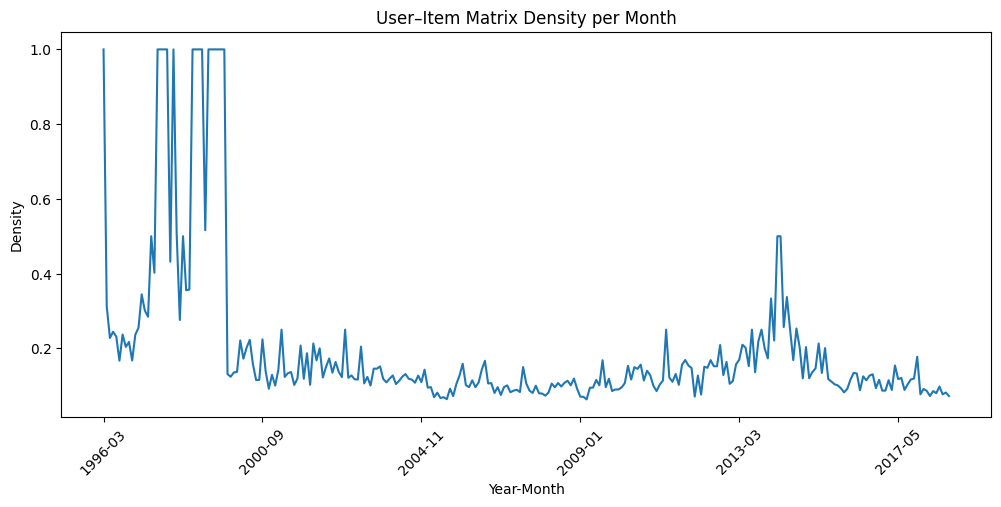

In [155]:
monthly_stats['density'].plot(figsize=(12,5))

plt.title("User–Item Matrix Density per Month")
plt.xlabel("Year-Month")
plt.ylabel("Density")
plt.xticks(rotation=45)
plt.show()

The user–item matrix remains highly sparse throughout the dataset’s lifetime. After initial instability due to small sample sizes, density stabilizes at low levels (~0.1–0.2). This implies that pure collaborative filtering may struggle due to limited overlap between users. A hybrid approach combining collaborative and content signals is likely necessary.

### 4.2 User life cycle pattern

#### 4.2.1 Are ratings clustered (burst behavior)?

In [156]:
user_lifecycle = ratings.groupby('userId').agg(
    first_rating=('datetime', 'min'),
    last_rating=('datetime', 'max'),
    ratings_count=('rating', 'count')
)

user_lifecycle['lifespan_days'] = (
    user_lifecycle['last_rating'] - user_lifecycle['first_rating']
).dt.days

print(user_lifecycle.head())

                    first_rating               last_rating  ratings_count  \
userId                                                                      
1      2000-07-30 18:08:19+00:00 2000-08-08 07:27:42+00:00            232   
2      2015-10-24 19:27:15+00:00 2015-10-24 19:35:40+00:00             29   
3      2011-05-27 02:28:43+00:00 2011-05-27 02:44:53+00:00             39   
4      1999-12-13 09:47:08+00:00 2001-12-05 17:49:02+00:00            216   
5      1996-11-08 06:32:27+00:00 1996-11-08 06:42:17+00:00             44   

        lifespan_days  
userId                 
1                   8  
2                   0  
3                   0  
4                 723  
5                   0  


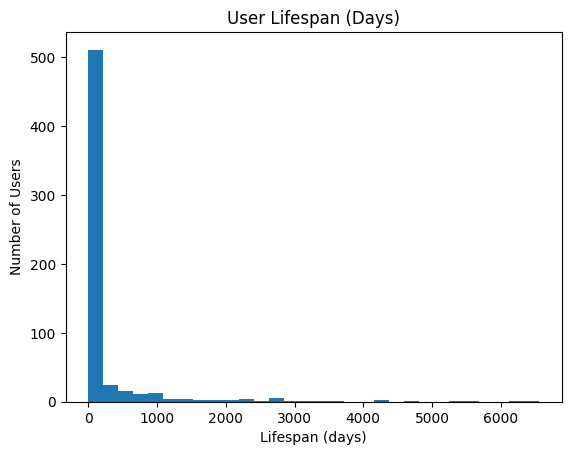

In [157]:
plt.hist(user_lifecycle['lifespan_days'], bins=30)
plt.title("User Lifespan (Days)")
plt.xlabel("Lifespan (days)")
plt.ylabel("Number of Users")
plt.show()

The lifespan distribution is highly skewed. A large majority of users have very short activity spans, indicating burst-like rating behavior. A small minority of users exhibit long-term engagement over several years. This suggests that user activity is session-based rather than continuous, which has implications for time-aware recommendation strategies.

In [159]:
user_lifecycle['ratings_per_day'] = (
    user_lifecycle['ratings_count'] /
    (user_lifecycle['lifespan_days'] + 1)
)

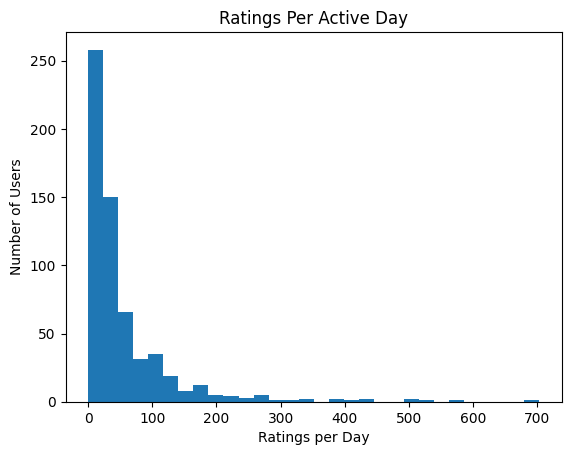

In [160]:
plt.hist(user_lifecycle['ratings_per_day'], bins=30)
plt.title("Ratings Per Active Day")
plt.xlabel("Ratings per Day")
plt.ylabel("Number of Users")
plt.show()

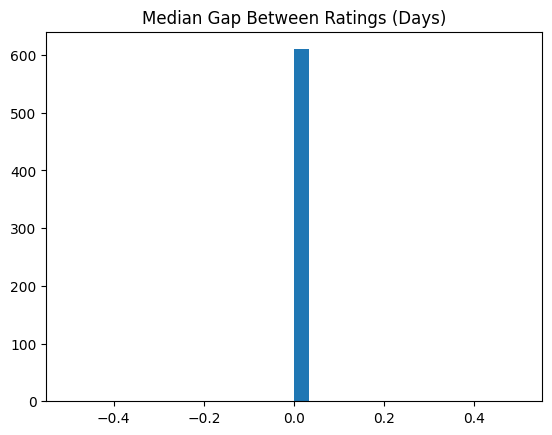

In [161]:
ratings_sorted = ratings.sort_values(['userId', 'datetime'])

ratings_sorted['time_diff'] = ratings_sorted.groupby('userId')['datetime'].diff()

median_gap = ratings_sorted.groupby('userId')['time_diff'].median()

median_gap_days = median_gap.dt.days

plt.hist(median_gap_days.dropna(), bins=30)
plt.title("Median Gap Between Ratings (Days)")
plt.show()



 📌 Modeling Implications — User Burst Behavior

The user lifecycle and activity intensity analysis reveals strong burst dynamics in the dataset.

 1️⃣ Highly Session-Based Rating Behavior

The **Ratings Per Active Day** distribution is heavily right-skewed:

* Many users exhibit extremely high ratings per active day.
* A large portion of users rate many movies within a very short lifespan.
* This indicates ratings are concentrated in short sessions rather than evenly distributed over time.

This suggests user interaction is episodic rather than continuous.

---

 2️⃣ Minimal Temporal Gaps Between Ratings

The **Median Gap Between Ratings** is close to zero for most users.

This implies:

* Ratings are frequently made on the same day.
* Users tend to rate multiple movies in clusters.
* Long periods of inactivity are common after initial bursts.

This further confirms burst-like interaction patterns.

---

3️⃣ Implications for Recommendation Modeling

Based on these findings, the following modeling considerations emerge:

---

✅ A. Time Decay Should Be Considered

Because user activity is burst-driven:

* Older ratings may not reflect current preferences.
* Recent ratings likely capture short-term taste more accurately.

A time-aware weighting scheme (e.g., exponential decay or recency boosting) could improve personalization.

---
✅ B. Session-Level Signals Are Strong

Since users rate many items in a short period:

* Movies rated within the same session likely share thematic or contextual similarity.
* Boosting items similar to recently rated movies could improve relevance.

In production systems, session-based recommendation logic would be beneficial.

---
 ✅ C. Cold-Start Remains Structural

Given the short lifespan of many users:

* Many users will never accumulate large interaction histories.
* The system must perform well with limited signals.

This strengthens the case for:

* Hybrid recommendation (collaborative + content)
* Strong onboarding mechanisms
* Popularity-aware fallback strategies

---

✅ D. Long-Term Preference Modeling Should Be Secondary

Since sustained engagement is rare:

* Building complex long-term user embeddings may offer limited returns.
* Emphasizing short-term behavior may yield better gains.

---

🎯 Strategic Conclusion

The dataset exhibits strong burst behavior with clustered ratings and minimal sustained engagement. Therefore:

> A hybrid recommender with recency-aware weighting and session-sensitive ranking is more appropriate than a purely static collaborative filtering model.


### 4.3 Recency Effects

          mean  median  count
year                         
1996  3.535927     3.0   6040
1997  3.727557     4.0   1916
1998  3.435897     4.0    507
1999  3.772448     4.0   2439
2000  3.392506     3.0  10061
2001  3.512239     4.0   3922
2002  3.606958     4.0   3478
2003  3.499377     3.5   4014
2004  3.506099     3.5   3279
2005  3.431533     3.5   5813
2006  3.487928     3.5   4059
2007  3.309039     3.5   7114
2008  3.656746     4.0   4351
2009  3.392496     3.5   4158
2010  3.463494     3.5   2301
2011  3.784024     4.0   1690
2012  3.641323     4.0   4656
2013  3.877404     4.0   1664
2014  3.510771     3.5   1439
2015  3.513830     3.5   6616
2016  3.686334     4.0   6703
2017  3.348805     3.5   8198
2018  3.389062     3.5   6418


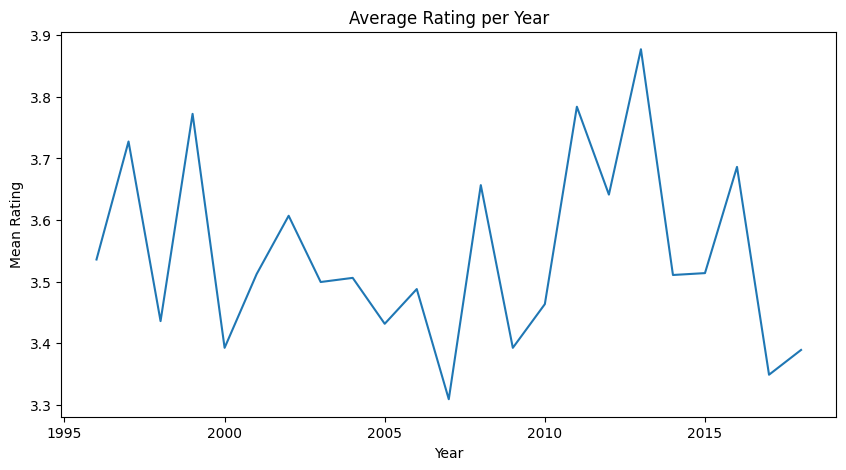

In [164]:
rating_trend = ratings.groupby('year')['rating'].agg(['mean', 'median', 'count'])
print(rating_trend)
rating_trend['mean'].plot(figsize=(10,5))

plt.title("Average Rating per Year")
plt.xlabel("Year")
plt.ylabel("Mean Rating")
plt.show()


age_bin
0-1      3.472712
1-5      3.445922
5-10     3.456431
10-20    3.446682
20-50    3.658474
50+      3.786652
Name: rating, dtype: float64


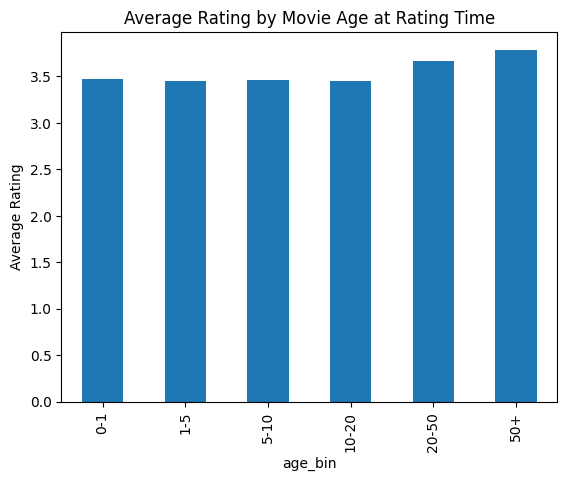

In [165]:
import re

movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')
ratings_movies = ratings.merge(
    movies[['movieId', 'release_year']],
    on='movieId',
    how='left'
)
ratings_movies['movie_age_at_rating'] = (
    ratings_movies['year'] - ratings_movies['release_year']
)
ratings_movies = ratings_movies[
    ratings_movies['movie_age_at_rating'] >= 0
]
ratings_movies['age_bin'] = pd.cut(
    ratings_movies['movie_age_at_rating'],
    bins=[0,1,5,10,20,50,100],
    labels=["0-1","1-5","5-10","10-20","20-50","50+"]
)
age_effect = ratings_movies.groupby('age_bin')['rating'].mean()

print(age_effect)
age_effect.plot(kind='bar')

plt.title("Average Rating by Movie Age at Rating Time")
plt.ylabel("Average Rating")
plt.show()

**Explanation:** 🎈

The chart shows that average ratings are relatively stable for newer movies (0–20 years old), hovering around ~3.45–3.5, but increase noticeably for older films, particularly those 20–50 years old and 50+ years old, which reach averages closer to ~3.65–3.8. This suggests a mild but clear “classic bias”: older movies tend to receive higher ratings than more recent releases. The difference is not extreme, but it is consistent enough to indicate that movie age influences rating behavior. Rather than a novelty bias toward new releases, the data suggests that older films—likely well-known or culturally validated titles—receive systematically higher evaluations.

**Modeling Implications:** ⚡

This age-based rating bias implies that a naive recommender relying heavily on average rating may over-recommend older “classic” movies and under-represent newer releases. To avoid this bias, the model may need normalization strategies such as adjusting ratings by movie age or incorporating recency-aware features into the ranking formula. Additionally, if the goal is to balance discovery and relevance, the system could introduce controlled boosting for newer films to prevent long-tail collapse into highly rated classics. Overall, incorporating movie-age features or light temporal normalization would improve fairness and diversity in the recommendation output.


### 4.4 Chapter summary 



**Chapter 4 — Temporal Analysis: Summary**

This chapter examined temporal dynamics in the MovieLens dataset, focusing on rating activity over time, matrix density evolution, user lifecycle behavior, and recency effects. The goal was to understand how time influences user behavior and its implications for recommendation modeling.

Rating activity analysis showed fluctuations across years, with early instability due to small sample sizes and later stabilization. However, user–item matrix density steadily decreased and stabilized at very low levels (~4–6%), confirming extreme sparsity. This indicates limited overlap between users and suggests that pure collaborative filtering may struggle without additional signals.

User lifecycle analysis revealed highly burst-driven behavior. Most users exhibit very short activity spans, rating multiple movies within a short time window and then becoming inactive. The ratings-per-active-day distribution confirmed that interactions are clustered rather than evenly distributed over time. Only a small minority of users demonstrate long-term sustained engagement. This indicates that user activity is session-based rather than continuous.

Recency analysis showed no strong novelty bias toward new releases. Instead, older movies (particularly 20+ years old) tend to receive slightly higher average ratings, suggesting a mild “classic bias.” This implies that raw average rating may favor older catalog titles if left unadjusted.

---

**Strategic Implications**

The temporal structure of the dataset leads to several important modeling conclusions:

1. The matrix remains highly sparse over time, reinforcing the need for a hybrid recommendation approach.
2. User behavior is burst-heavy, suggesting that recent interactions should potentially carry more weight than distant historical ratings.
3. Cold-start remains a structural challenge due to short user lifespans.
4. Age-based rating bias suggests the need for either normalization or controlled recency balancing in ranking.

Overall, the temporal analysis supports the design of a hybrid recommender that incorporates collaborative signals, content features, and light time-awareness rather than relying on static collaborative filtering alone.

---




## 5.  Movie & Genre Analysis

### 5.1 Genre Distribution


#### Movie stats distribution

In [5]:
movie_stats_exploded = (
    movie_stats_df
    .assign(genres=movie_stats_df['genres'].str.split('|'))
    .explode('genres')
).reset_index(names='movieID')
print(movie_stats_exploded[['genres', 'title']])

          genres                             title
0         Comedy               Forrest Gump (1994)
1          Drama               Forrest Gump (1994)
2        Romance               Forrest Gump (1994)
3            War               Forrest Gump (1994)
4          Crime  Shawshank Redemption, The (1994)
...          ...                               ...
22041   Children            The Emoji Movie (2017)
22042     Comedy            The Emoji Movie (2017)
22043     Action   Fullmetal Alchemist 2018 (2017)
22044  Adventure   Fullmetal Alchemist 2018 (2017)
22045    Fantasy   Fullmetal Alchemist 2018 (2017)

[22046 rows x 2 columns]


#### Genres with most movies

In [6]:
all_genres = movie_stats_exploded.groupby('genres')['movieId'].nunique().reset_index(name='num_movies')
all_genres.sort_values('num_movies', inplace=True, ascending=False)
print(all_genres)


                genres  num_movies
8                Drama        4349
5               Comedy        3753
17            Thriller        1889
1               Action        1828
15             Romance        1591
2            Adventure        1262
6                Crime        1196
16              Sci-Fi         980
11              Horror         977
9              Fantasy         778
4             Children         664
3            Animation         610
14             Mystery         573
7          Documentary         438
18                 War         381
13             Musical         333
19             Western         167
12                IMAX         158
10           Film-Noir          85
0   (no genres listed)          34


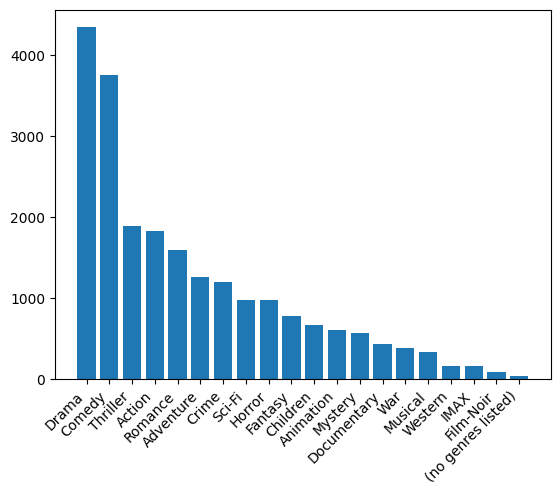

In [7]:
import matplotlib.pyplot as plt
plt.bar(all_genres['genres'], all_genres['num_movies'])
plt.xticks(rotation=45, ha='right')
plt.show()

#### Rating per genre distro

In [8]:
ratings_with_genres = ratings.merge(
    movies[['movieId', 'genres']],
    on='movieId',
    how='left'
)
ratings_with_genres = (
    ratings_with_genres
    .assign(genres=ratings_with_genres['genres'].str.split('|'))
    .explode('genres')
)
genre_stats = (
    ratings_with_genres
    .groupby('genres')
    .agg(
        avg_rating=('rating', 'mean'),
        std_rating=('rating', 'std'),
        median_rating=('rating', 'median'),
        num_ratings=('rating', 'size'),
        num_users=('userId', 'nunique'),
        num_movies=('movieId', 'nunique')
    )
    .reset_index()
)
print(genre_stats.head(20))

                genres  avg_rating  std_rating  median_rating  num_ratings  \
0   (no genres listed)    3.489362    1.218023            3.5           47   
1               Action    3.447984    1.050930            3.5        30635   
2            Adventure    3.508609    1.029073            3.5        24161   
3            Animation    3.629937    0.969664            4.0         6988   
4             Children    3.412956    1.055996            3.5         9208   
5               Comedy    3.384721    1.066541            3.5        39053   
6                Crime    3.658294    0.994673            4.0        16681   
7          Documentary    3.797785    0.820461            4.0         1219   
8                Drama    3.656184    0.979133            4.0        41928   
9              Fantasy    3.491001    1.038688            3.5        11834   
10           Film-Noir    3.920115    0.886997            4.0          870   
11              Horror    3.258195    1.142591            3.5   

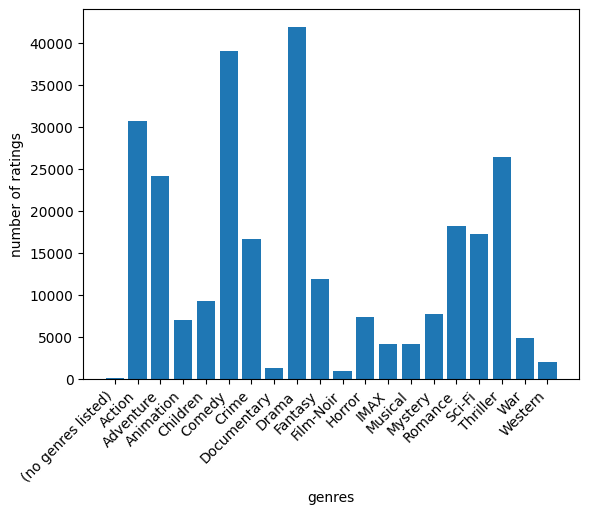

In [9]:
plt.bar(genre_stats['genres'], genre_stats['num_ratings'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('genres')
plt.ylabel('number of ratings')
plt.show()

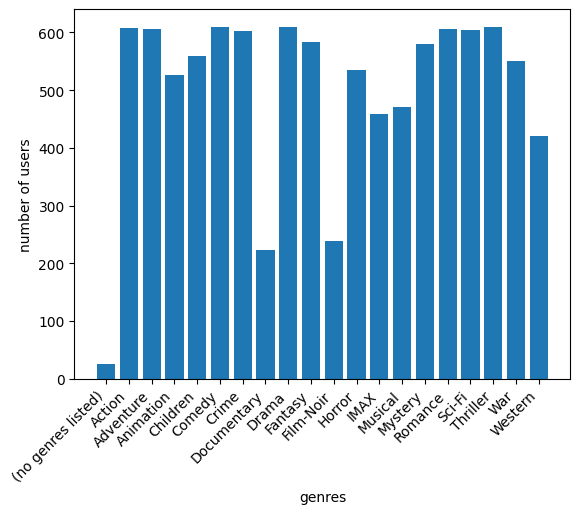

In [10]:
plt.bar(genre_stats['genres'], genre_stats['num_users'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('genres')
plt.ylabel('number of users')
plt.show()

### 5.2 Genre Co-Occurrence

In [11]:
movies_exploded = movies.copy()
movies_exploded['genres'] = movies_exploded['genres'].str.split('|')
movies_exploded = movies_exploded.explode('genres')

In [15]:
from itertools import combinations
movie_genre_lists = movies_exploded.groupby('movieId')['genres'].apply(list)

genre_pairs = []

for genres in movie_genre_lists:
    if len(genres) > 1:
        pairs = combinations(sorted(genres), 2)
        genre_pairs.extend(pairs)

In [16]:
import pandas as pd

genre_pair_counts = pd.Series(genre_pairs).value_counts()

print(genre_pair_counts.head(20))

(Comedy, Drama)          1013
(Drama, Romance)          934
(Comedy, Romance)         884
(Drama, Thriller)         832
(Action, Thriller)        655
(Crime, Drama)            637
(Action, Adventure)       610
(Crime, Thriller)         569
(Action, Drama)           529
(Horror, Thriller)        459
(Action, Sci-Fi)          451
(Action, Comedy)          429
(Action, Crime)           418
(Adventure, Comedy)       399
(Children, Comedy)        362
(Mystery, Thriller)       354
(Comedy, Crime)           345
(Adventure, Fantasy)      334
(Adventure, Children)     312
(Adventure, Drama)        311
Name: count, dtype: int64


In [17]:
import pandas as pd
from itertools import combinations
from collections import Counter

# split genres into lists
genre_lists = movies['genres'].str.split('|')

# build all pairs per movie
pairs = []
for gs in genre_lists:
    gs = [g for g in gs if g and g != '(no genres listed)']
    if len(gs) >= 2:
        pairs.extend(combinations(sorted(set(gs)), 2))  # set() avoids duplicate genres

pair_counts = Counter(pairs)

# convert to df
edges = pd.DataFrame(
    [(a, b, w) for (a, b), w in pair_counts.items()],
    columns=['genre1', 'genre2', 'weight']
)

edges_sorted = edges.sort_values('weight', ascending=False)
edges_sorted.head(500)

,genre1,genre2,weight
11,Comedy,Drama,1013
12,Drama,Romance,934
10,Comedy,Romance,884
26,Drama,Thriller,832
14,Action,Thriller,655
...,...,...,...
160,Documentary,Mystery,2
116,Fantasy,Film-Noir,1
154,Children,Documentary,1
162,Documentary,Western,1


Nodes: 3
Edges: 2


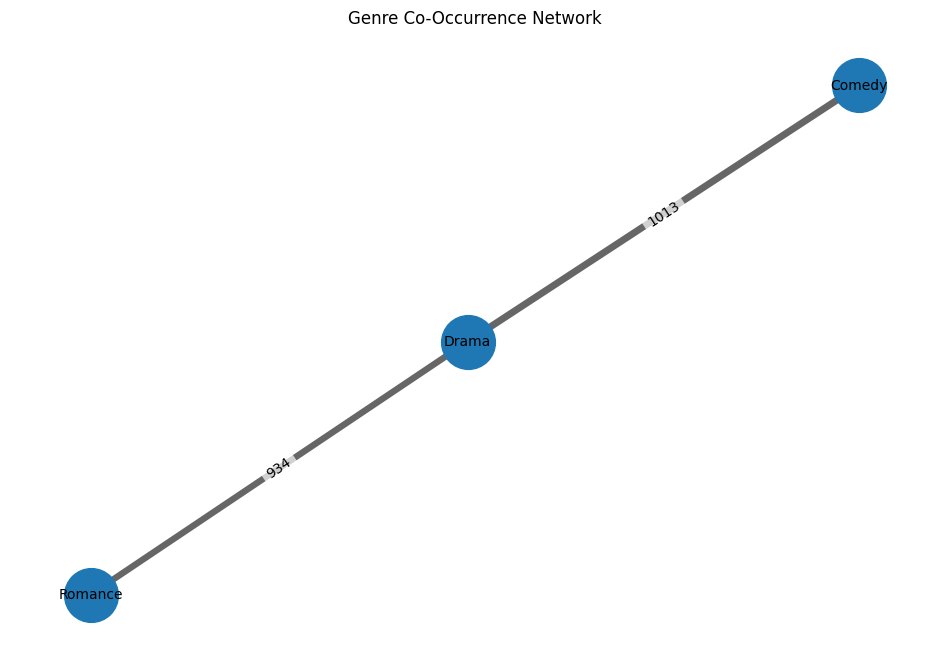

In [30]:
import networkx as nx

G = nx.Graph()
top_edges = edges.sort_values('weight', ascending=False).head(15)

G = nx.Graph()

threshold = edges['weight'].quantile(0.99)

for _, row in edges.iterrows():
    if row['weight'] >= threshold:
        G.add_edge(row['genre1'], row['genre2'], weight=row['weight'])

import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 8))

# layout
pos = nx.spring_layout(G, seed=42, k=0.8)

# edge weights
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(edge_weights)

# normalize thickness
edge_widths = [w / max_weight * 5 for w in edge_weights]
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
# draw
nx.draw_networkx_nodes(G, pos, node_size=1500)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10)
edge_labels = {(u, v): d["weight"] for u, v, d in G.edges(data=True)}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=10,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.title("Genre Co-Occurrence Network")
plt.axis('off')
plt.show()

In [ ]:
#get all of the combinations
# Clean genres
movies_clean = movies[['movieId', 'genres']].copy()
movies_clean = movies_clean[movies_clean['genres'] != '(no genres listed)']

# Normalize ordering so combinations are consistent
movies_clean['genres_sorted'] = (
    movies_clean['genres']
    .str.split('|')
    .apply(lambda x: '|'.join(sorted(x)))
)

# Count full combinations
combo_counts = movies_clean['genres_sorted'].value_counts()
print(combo_counts.head(15))

genres_sorted
Drama                   1053
Comedy                   946
Comedy|Drama             435
Comedy|Romance           363
Drama|Romance            349
Documentary              339
Comedy|Drama|Romance     276
Drama|Thriller           168
Horror                   167
Horror|Thriller          135
Crime|Drama              134
Crime|Drama|Thriller     125
Drama|War                114
Comedy|Crime             101
Action|Comedy             92
Name: count, dtype: int64


In [20]:
two_genre_combos = combo_counts[
    combo_counts.index.str.count(r'\|') == 1
]

print(two_genre_combos.head(10))

genres_sorted
Comedy|Drama       435
Comedy|Romance     363
Drama|Romance      349
Drama|Thriller     168
Horror|Thriller    135
Crime|Drama        134
Drama|War          114
Comedy|Crime       101
Action|Comedy       92
Children|Comedy     74
Name: count, dtype: int64


In [21]:
three_genre_combos = combo_counts[
    combo_counts.index.str.count(r'\|') == 2
]

print(three_genre_combos.head(10))

genres_sorted
Comedy|Drama|Romance        276
Crime|Drama|Thriller        125
Action|Crime|Thriller        66
Action|Adventure|Sci-Fi      66
Action|Crime|Drama           50
Action|Sci-Fi|Thriller       43
Action|Drama|Thriller        43
Action|Comedy|Crime          42
Horror|Mystery|Thriller      42
Action|Adventure|Fantasy     41
Name: count, dtype: int64


In [22]:
four_genre_combos = combo_counts[
    combo_counts.index.str.count(r'\|') == 3
]

print(four_genre_combos.head(10))

genres_sorted
Action|Crime|Drama|Thriller            61
Crime|Drama|Mystery|Thriller           34
Adventure|Animation|Children|Comedy    31
Action|Adventure|Sci-Fi|Thriller       27
Action|Comedy|Crime|Thriller           22
Action|Adventure|Drama|War             22
Drama|Horror|Mystery|Thriller          20
Action|Adventure|IMAX|Sci-Fi           18
Action|Adventure|Fantasy|Sci-Fi        17
Action|Horror|Sci-Fi|Thriller          16
Name: count, dtype: int64


In [23]:
five_genre_combos = combo_counts[
    combo_counts.index.str.count(r'\|') == 4
]

print(five_genre_combos.head(10))

genres_sorted
Adventure|Animation|Children|Comedy|Fantasy     13
Action|Crime|Drama|Mystery|Thriller             10
Crime|Drama|Mystery|Romance|Thriller             7
Action|Adventure|Drama|Sci-Fi|Thriller           7
Action|Comedy|Crime|Drama|Thriller               6
Action|Adventure|Animation|Fantasy|Sci-Fi        6
Action|Adventure|IMAX|Sci-Fi|Thriller            5
Action|Adventure|Animation|Children|Comedy       5
Adventure|Animation|Children|Comedy|Musical      4
Adventure|Animation|Children|Fantasy|Musical     4
Name: count, dtype: int64


In [24]:
six_genre_combos = combo_counts[
    combo_counts.index.str.count(r'\|') == 5
]

print(six_genre_combos.head(10))

genres_sorted
Adventure|Animation|Children|Comedy|Fantasy|Romance     3
Action|Adventure|Animation|Children|Fantasy|Sci-Fi      3
Action|Adventure|Animation|Children|Comedy|Fantasy      3
Action|Adventure|Animation|Children|Comedy|Sci-Fi       3
Adventure|Animation|Children|Comedy|Fantasy|IMAX        3
Adventure|Animation|Children|Fantasy|Musical|Romance    2
Adventure|Animation|Children|Comedy|Fantasy|Sci-Fi      2
Action|Adventure|Comedy|Fantasy|Horror|Thriller         2
Action|Adventure|Animation|Children|Comedy|IMAX         2
Action|Crime|Drama|Mystery|Sci-Fi|Thriller              1
Name: count, dtype: int64


In [25]:
seven_genre_combos = combo_counts[
    combo_counts.index.str.count(r'\|') == 6
]

print(seven_genre_combos.head(10))

genres_sorted
Adventure|Animation|Children|Comedy|Drama|Musical|Romance      1
Adventure|Animation|Children|Comedy|Crime|Fantasy|Mystery      1
Action|Animation|Comedy|Crime|Drama|Romance|Thriller           1
Adventure|Comedy|Drama|Fantasy|Mystery|Sci-Fi|Thriller         1
Adventure|Animation|Children|Comedy|Fantasy|IMAX|Sci-Fi        1
Action|Drama|Fantasy|Horror|Mystery|Sci-Fi|Thriller            1
Action|Adventure|Animation|Comedy|Fantasy|Mystery|Sci-Fi       1
Adventure|Animation|Children|Comedy|Fantasy|Musical|Romance    1
Action|Adventure|Drama|Fantasy|Romance|Sci-Fi|Thriller         1
Action|Crime|Drama|IMAX|Mystery|Sci-Fi|Thriller                1
Name: count, dtype: int64


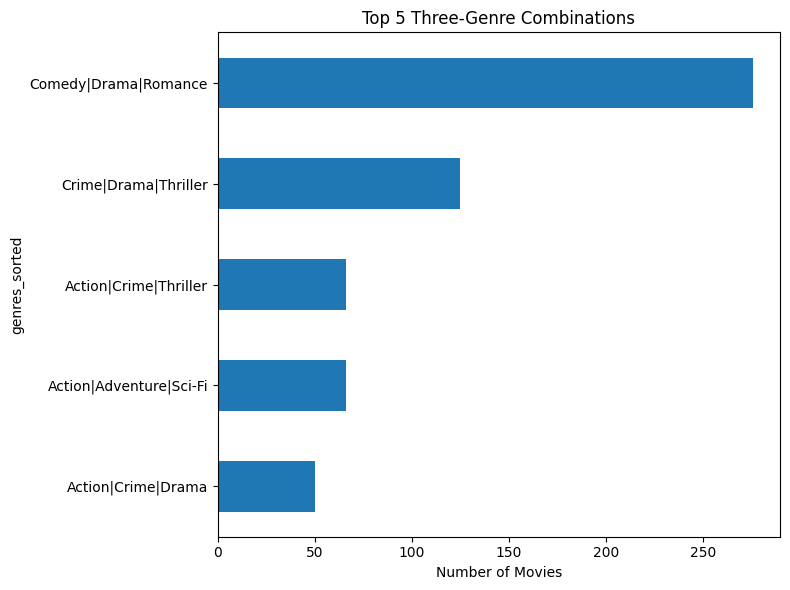

In [29]:
top_3 = three_genre_combos.sort_values(ascending=False).head(5)

plt.figure(figsize=(8,6))
top_3.sort_values().plot(kind='barh')

plt.title("Top 5 Three-Genre Combinations")
plt.xlabel("Number of Movies")
plt.tight_layout()
plt.show()

## 6. Tags Signal Exploration

In [31]:
tags.info()
tags.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     3683 non-null   int64
 1   movieId    3683 non-null   int64
 2   tag        3683 non-null   str  
 3   timestamp  3683 non-null   int64
dtypes: int64(3), str(1)
memory usage: 115.2 KB


userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

In [32]:
tags['tag'] = tags['tag'].str.lower()

In [33]:
tags['tag'] = tags['tag'].str.replace(r'\s+', ' ', regex=True)

In [35]:
tag_counts = tags['tag'].value_counts()
print(tag_counts)

tag
in netflix queue    131
atmospheric          41
funny                24
superhero            24
surreal              24
                   ... 
romans                1
70mm                  1
for katie             1
austere               1
gun fu                1
Name: count, Length: 1475, dtype: int64


In [36]:
valid_tags = tag_counts[tag_counts >= 3].index
tags = tags[tags['tag'].isin(valid_tags)]

In [37]:
tags['timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')

In [38]:
movie_tags = (
    tags.groupby('movieId')['tag']
    .apply(list)
    .reset_index()
)

In [39]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

tags['tag'] = tags['tag'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

movie_tags['tag_string'] = movie_tags['tag'].apply(lambda x: " ".join(x))

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(movie_tags['tag_string'])

In [41]:
tags_per_movie = tags.groupby('movieId').size()
tags_per_user = tags.groupby('userId').size()

print(tags_per_movie.describe())
print(tags_per_user.describe())

count    1202.000000
mean        1.925125
std         3.087303
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        70.000000
dtype: float64
count      47.000000
mean       49.234043
std       159.526775
min         1.000000
25%         2.000000
50%         2.000000
75%        16.500000
max      1030.000000
dtype: float64


In [42]:

n_tags = len(tags)
n_tag_users = tags['userId'].nunique()
n_tag_movies = tags['movieId'].nunique()

print(n_tags, n_tag_users, n_tag_movies)

tags_per_movie = tags.groupby('movieId').size()
tags_per_user  = tags.groupby('userId').size()

print(tags_per_movie.describe())
print(tags_per_user.describe())

2314 47 1202
count    1202.000000
mean        1.925125
std         3.087303
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        70.000000
dtype: float64
count      47.000000
mean       49.234043
std       159.526775
min         1.000000
25%         2.000000
50%         2.000000
75%        16.500000
max      1030.000000
dtype: float64


In [44]:
#tags is useless let's use links and tmbd id
print(links.isnull().sum())

movieId    0
imdbId     0
tmdbId     8
dtype: int64
